In [109]:
from cyvcf2 import VCF
import pandas as pd
import numpy as np

def vcf_to_dataframe(vcf_path):
    """
    Reads a .vcf or .vcf.gz using cyvcf2 and returns a pandas DataFrame
    with:
    - basic variant fields
    - GT as string (0/1, 1/1, etc.)
    - a single 'FORMAT' column with all FORMAT fields except GT and PS
    """
    vcf = VCF(vcf_path)
    records = []

    for var in vcf:
        # Basic variant info
        chrom = var.CHROM
        pos = var.POS
        ref = var.REF
        alt = ",".join(var.ALT)
        qual = var.QUAL
        filt = var.FILTER or "PASS"
        info = dict(var.INFO)

        # GT as string
        gt = var.genotypes[0] if var.genotypes else None
        gt_str = "/".join(map(str, gt[:2])) if gt else "./."

        # Collect FORMAT fields except GT and PS
        format_dict = {}
        if hasattr(var, "FORMAT") and var.FORMAT:
            for key in var.FORMAT:
                if key in ["GT", "PS"]:
                    continue  # skip GT and PS
                try:
                    val = var.format(key)
                    if val is None or len(val) == 0:
                        format_dict[key] = '.'
                    else:
                        v = val[0]  # first sample
                        if isinstance(v, np.ndarray):
                            format_dict[key] = ",".join(map(str, v))
                        else:
                            format_dict[key] = str(v)
                        if format_dict[key] in ['-2147483648', '-1']:
                            format_dict[key] = '.'
                except Exception:
                    format_dict[key] = '.'

        # Build record
        record = {
            "CHROM": chrom,
            "POS": pos,
            "REF": ref,
            "ALT": alt,
            "QUAL": qual,
            "FILTER": filt,
            "GT": gt_str,
            "INFO": info,
            "FORMAT": format_dict  # all other FORMAT fields as dict
        }

        records.append(record)

    return pd.DataFrame(records)


In [110]:
HG001 = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/GIAB/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz")
HG002 = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/GIAB/HG002_GRCh38_1_22_v4.2.1_benchmark.vcf.gz")
HG005 = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/GIAB/HG005_GRCh38_1_22_v4.2.1_benchmark.vcf.gz")

In [117]:
HG001

,CHROM,POS,REF,ALT,QUAL,FILTER,GT,INFO,FORMAT
0,chr1,783006,A,G,50.0,PASS,1/1,"{'platforms': 4, 'platformnames': 'PacBio,Illu...","{'DP': '652', 'ADALL': '16,234', 'AD': '0,82',..."
1,chr1,783175,T,C,50.0,PASS,1/1,"{'platforms': 4, 'platformnames': 'PacBio,Illu...","{'DP': '639', 'ADALL': '0,218', 'AD': '0,84', ..."
2,chr1,784860,T,C,50.0,PASS,1/1,"{'platforms': 4, 'platformnames': 'PacBio,Illu...","{'DP': '901', 'ADALL': '105,406', 'AD': '0,74'..."
3,chr1,785417,G,A,50.0,PASS,1/1,"{'platforms': 4, 'platformnames': 'PacBio,Illu...","{'DP': '820', 'ADALL': '125,383', 'AD': '0,70'..."
4,chr1,797392,G,A,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '760', 'ADALL': '161,142', 'AD': '25,37..."
...,...,...,...,...,...,...,...,...,...
3893336,chr22,50791190,G,A,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '498', 'ADALL': '87,65', 'AD': '35,35',..."
3893337,chr22,50792075,G,T,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '545', 'ADALL': '144,36', 'AD': '34,37'..."
3893338,chr22,50792591,T,C,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '677', 'ADALL': '123,132', 'AD': '37,33..."
3893339,chr22,50792792,A,G,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '392', 'ADALL': '56,49', 'AD': '33,36',..."


In [119]:
HG005

,CHROM,POS,REF,ALT,QUAL,FILTER,GT,INFO,FORMAT
0,chr1,613111,C,T,50.0,PASS,1/1,"{'platforms': 4, 'platformnames': 'PacBio,10X,...","{'DP': '292', 'ADALL': '0,83', 'AD': '0,68', '..."
1,chr1,623924,A,G,50.0,PASS,1/0,"{'platforms': 3, 'platformnames': 'PacBio,10X,...","{'DP': '659', 'ADALL': '190,49', 'AD': '22,19'..."
2,chr1,627528,A,G,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': 'PacBio,10X,...","{'DP': '265', 'ADALL': '0,67', 'AD': '0,75', '..."
3,chr1,628245,T,C,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': 'PacBio,10X,...","{'DP': '277', 'ADALL': '0,84', 'AD': '0,64', '..."
4,chr1,629660,C,T,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': '10X,PacBio,...","{'DP': '730', 'ADALL': '152,148', 'AD': '15,15..."
...,...,...,...,...,...,...,...,...,...
3856851,chr22,50781400,A,AAGAGAGAGAG,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '281', 'ADALL': '31,26', 'AD': '21,17',..."
3856852,chr22,50782013,T,C,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': '10X,PacBio,...","{'DP': '587', 'ADALL': '0,227', 'AD': '1,65', ..."
3856853,chr22,50788602,A,G,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '707', 'ADALL': '2,319', 'AD': '0,37', ..."
3856854,chr22,50789509,A,C,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': '10X,PacBio,...","{'DP': '749', 'ADALL': '0,322', 'AD': '0,36', ..."


In [38]:
def split_multi_alt(df):
    """
    Splits rows with multiple ALT alleles into separate rows.
    
    Args:
        df (pd.DataFrame): DataFrame from vcf_to_dataframe()
    
    Returns:
        pd.DataFrame: Expanded DataFrame, one row per ALT allele.
    """
    rows = []

    for idx, row in df.iterrows():
        alts = row["ALT"].split(",")
        gt = row["GT"]

        for i, alt in enumerate(alts):
            # Optionally, adjust GT per allele (0/1, 0/2 etc.)
            gt_split = gt
            if gt not in ["./.", "."]:
                alleles = gt.replace("|","/").split("/")
                # Map alleles to this ALT
                new_alleles = []
                for a in alleles:
                    if a == str(i+1):
                        new_alleles.append("1")
                    elif a == "0":
                        new_alleles.append("0")
                    else:
                        new_alleles.append("0")  # treat other ALT as reference
                gt_split = "/".join(new_alleles)
            
            new_row = row.copy()
            new_row["ALT"] = alt
            new_row["GT"] = gt_split
            rows.append(new_row)

    return pd.DataFrame(rows).reset_index(drop=True)

In [20]:
HG001_split = split_multi_alt(HG001)
HG002_split = split_multi_alt(HG002)
HG005_split = split_multi_alt(HG005)

In [39]:
HG005_split = split_multi_alt(HG005)

In [40]:
HG005_split

,CHROM,POS,REF,ALT,QUAL,FILTER,GT,INFO,FORMAT
0,chr1,613111,C,T,50.0,PASS,1/1,"{'platforms': 4, 'platformnames': 'PacBio,10X,...","{'DP': '292', 'ADALL': '0,83', 'AD': '0,68', '..."
1,chr1,623924,A,G,50.0,PASS,1/0,"{'platforms': 3, 'platformnames': 'PacBio,10X,...","{'DP': '659', 'ADALL': '190,49', 'AD': '22,19'..."
2,chr1,627528,A,G,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': 'PacBio,10X,...","{'DP': '265', 'ADALL': '0,67', 'AD': '0,75', '..."
3,chr1,628245,T,C,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': 'PacBio,10X,...","{'DP': '277', 'ADALL': '0,84', 'AD': '0,64', '..."
4,chr1,629660,C,T,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': '10X,PacBio,...","{'DP': '730', 'ADALL': '152,148', 'AD': '15,15..."
...,...,...,...,...,...,...,...,...,...
3887805,chr22,50781400,A,AAGAGAGAGAG,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '281', 'ADALL': '31,26', 'AD': '21,17',..."
3887806,chr22,50782013,T,C,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': '10X,PacBio,...","{'DP': '587', 'ADALL': '0,227', 'AD': '1,65', ..."
3887807,chr22,50788602,A,G,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '707', 'ADALL': '2,319', 'AD': '0,37', ..."
3887808,chr22,50789509,A,C,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': '10X,PacBio,...","{'DP': '749', 'ADALL': '0,322', 'AD': '0,36', ..."


In [21]:
import pandas as pd

def decompose_mnps(df):
    """
    Decompose multi-nucleotide polymorphisms (MNPs) in a VCF DataFrame into single SNPs.

    Assumes df has columns:
      - CHROM
      - POS
      - REF
      - ALT
      - other VCF fields (optional, preserved)
    
    Returns a new DataFrame where each base of an MNP is split into a single SNP.
    """
    decomposed_rows = []

    for _, row in df.iterrows():
        ref = row['REF']
        alt = row['ALT']

        # Only decompose if REF and ALT are same length > 1
        if len(ref) == len(alt) and len(ref) > 1:
            for i in range(len(ref)):
                new_row = row.copy()
                new_row['POS'] = row['POS'] + i
                new_row['REF'] = ref[i]
                new_row['ALT'] = alt[i]
                decomposed_rows.append(new_row)
        else:
            decomposed_rows.append(row)

    return pd.DataFrame(decomposed_rows)


In [22]:
HG001_norm = decompose_mnps(HG001_split)
HG002_norm = decompose_mnps(HG002_split)
HG005_norm = decompose_mnps(HG005_split)

In [24]:
HG001_norm.to_csv("HG001_norm_df.csv")
HG002_norm.to_csv("HG002_norm_df.csv")
HG005_norm.to_csv("HG005_norm_df.csv")

In [16]:
HG005_split[(HG005_split["CHROM"]=="chr1") & (HG005_split["POS"]==11154523)]

,CHROM,POS,REF,ALT,QUAL,FILTER,GT,INFO,FORMAT
14836,chr1,11154523,CTA,ATA,50.0,PASS,1/0,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '783', 'ADALL': '3,150,192', 'AD': '4,1..."
14837,chr1,11154523,CTA,C,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '783', 'ADALL': '3,150,192', 'AD': '4,1..."


In [17]:
df_norm[(df_norm["CHROM"] == "chr1") & 
        (df_norm["POS"] >= 11154523) & 
        (df_norm["POS"] <= 11154526)]

,CHROM,POS,REF,ALT,QUAL,FILTER,GT,INFO,FORMAT
14836,chr1,11154523,C,A,50.0,PASS,1/0,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '783', 'ADALL': '3,150,192', 'AD': '4,1..."
14836,chr1,11154524,T,T,50.0,PASS,1/0,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '783', 'ADALL': '3,150,192', 'AD': '4,1..."
14836,chr1,11154525,A,A,50.0,PASS,1/0,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '783', 'ADALL': '3,150,192', 'AD': '4,1..."
14837,chr1,11154523,CTA,C,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '783', 'ADALL': '3,150,192', 'AD': '4,1..."


In [23]:
HG005_norm[(HG005_norm["CHROM"] == "chr1") & 
        (HG005_norm["POS"] >= 11154523) & 
        (HG005_norm["POS"] <= 11154526)]

,CHROM,POS,REF,ALT,QUAL,FILTER,GT,INFO,FORMAT
14836,chr1,11154523,C,A,50.0,PASS,1/0,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '783', 'ADALL': '3,150,192', 'AD': '4,1..."
14836,chr1,11154524,T,T,50.0,PASS,1/0,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '783', 'ADALL': '3,150,192', 'AD': '4,1..."
14836,chr1,11154525,A,A,50.0,PASS,1/0,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '783', 'ADALL': '3,150,192', 'AD': '4,1..."
14837,chr1,11154523,CTA,C,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '783', 'ADALL': '3,150,192', 'AD': '4,1..."


In [3]:
import pandas as pd
HG001_norm=pd.read_csv("/mnt/genomics/Vinisha/WGS/scripts/HG001_norm_df.csv", index_col=0)
HG002_norm=pd.read_csv("/mnt/genomics/Vinisha/WGS/scripts/HG002_norm_df.csv", index_col=0)
HG005_norm=pd.read_csv("/mnt/genomics/Vinisha/WGS/scripts/HG005_norm_df.csv", index_col=0)

In [32]:
HG005_norm[HG005_norm["REF"] == HG005_norm["ALT"]]

,CHROM,POS,REF,ALT,QUAL,FILTER,GT,INFO,FORMAT
14836,chr1,11154524,T,T,50.0,PASS,1/0,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '783', 'ADALL': '3,150,192', 'AD': '4,1..."
14836,chr1,11154525,A,A,50.0,PASS,1/0,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '783', 'ADALL': '3,150,192', 'AD': '4,1..."
15251,chr1,11441088,T,T,50.0,PASS,0/1,"{'platforms': 4, 'platformnames': 'Illumina,Pa...","{'DP': '389', 'ADALL': '67,108,115', 'AD': '5,..."
15251,chr1,11441089,G,G,50.0,PASS,0/1,"{'platforms': 4, 'platformnames': 'Illumina,Pa...","{'DP': '389', 'ADALL': '67,108,115', 'AD': '5,..."
35413,chr1,25797150,G,G,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '149', 'ADALL': '0,39,54', 'AD': '0,36,..."
...,...,...,...,...,...,...,...,...,...
3840625,chr22,16254584,G,G,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '149', 'ADALL': '0,44,52', 'AD': '5,28,..."
3879999,chr22,46556038,A,A,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '231', 'ADALL': '0,82,108', 'AD': '0,82..."
3884372,chr22,48938207,A,A,50.0,PASS,0/1,"{'platforms': 1, 'platformnames': 'Illumina', ...","{'DP': '76', 'ADALL': '0,42,34', 'AD': '0,42,3..."
3884372,chr22,48938208,G,G,50.0,PASS,0/1,"{'platforms': 1, 'platformnames': 'Illumina', ...","{'DP': '76', 'ADALL': '0,42,34', 'AD': '0,42,3..."


NameError: name 'HG005_split' is not defined

In [31]:
HG005_norm

,CHROM,POS,REF,ALT,QUAL,FILTER,GT,INFO,FORMAT
0,chr1,613111,C,T,50.0,PASS,1/1,"{'platforms': 4, 'platformnames': 'PacBio,10X,...","{'DP': '292', 'ADALL': '0,83', 'AD': '0,68', '..."
1,chr1,623924,A,G,50.0,PASS,1/0,"{'platforms': 3, 'platformnames': 'PacBio,10X,...","{'DP': '659', 'ADALL': '190,49', 'AD': '22,19'..."
2,chr1,627528,A,G,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': 'PacBio,10X,...","{'DP': '265', 'ADALL': '0,67', 'AD': '0,75', '..."
3,chr1,628245,T,C,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': 'PacBio,10X,...","{'DP': '277', 'ADALL': '0,84', 'AD': '0,64', '..."
4,chr1,629660,C,T,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': '10X,PacBio,...","{'DP': '730', 'ADALL': '152,148', 'AD': '15,15..."
...,...,...,...,...,...,...,...,...,...
3887805,chr22,50781400,A,AAGAGAGAGAG,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '281', 'ADALL': '31,26', 'AD': '21,17',..."
3887806,chr22,50782013,T,C,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': '10X,PacBio,...","{'DP': '587', 'ADALL': '0,227', 'AD': '1,65', ..."
3887807,chr22,50788602,A,G,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '707', 'ADALL': '2,319', 'AD': '0,37', ..."
3887808,chr22,50789509,A,C,50.0,PASS,1/1,"{'platforms': 3, 'platformnames': '10X,PacBio,...","{'DP': '749', 'ADALL': '0,322', 'AD': '0,36', ..."


In [4]:
import pandas as pd

def get_unique_variants_combined(df1, df2):
    """
    Returns a single DataFrame containing variants unique to df1 or df2.
    Comparison is done using CHROM, POS, REF, ALT.

    Args:
        df1, df2 (pd.DataFrame): DataFrames with one row per ALT allele

    Returns:
        combined_unique_df (pd.DataFrame): Variants unique to either df1 or df2
    """
    df1 = df1.copy()
    df2 = df2.copy()

    # Create unique keys for each variant
    df1["VAR_KEY"] = df1["CHROM"].astype(str) + "_" + df1["POS"].astype(str) + "_" + df1["REF"] + "_" + df1["ALT"]
    df2["VAR_KEY"] = df2["CHROM"].astype(str) + "_" + df2["POS"].astype(str) + "_" + df2["REF"] + "_" + df2["ALT"]

    # Unique keys
    unique_keys_1 = set(df1["VAR_KEY"]) - set(df2["VAR_KEY"])
    unique_keys_2 = set(df2["VAR_KEY"]) - set(df1["VAR_KEY"])

    # Select unique variants from each
    unique_df1 = df1[df1["VAR_KEY"].isin(unique_keys_1)]
    unique_df2 = df2[df2["VAR_KEY"].isin(unique_keys_2)]

    # Combine into a single DataFrame
    combined_unique_df = pd.concat([unique_df1, unique_df2], axis=0)
    combined_unique_df = combined_unique_df.drop(columns=["VAR_KEY"]).reset_index(drop=True)

    return combined_unique_df


In [5]:
HG001_HG002_private = get_unique_variants_combined(HG001_norm, HG002_norm)
HG001_HG005_private = get_unique_variants_combined(HG001_norm, HG005_norm)
HG002_HG005_private = get_unique_variants_combined(HG002_norm, HG005_norm)

In [6]:
import pandas as pd

def classify_variant_type(ref, alt):
    """
    Classify variant as SNP, Insertion, Deletion, MNP, or Complex,
    and also return the length difference (LEN).

    LEN:
      - For SNP and MNP: number of bases changed (len(REF))
      - For Insertion: number of bases inserted (len(ALT) - len(REF))
      - For Deletion: number of bases deleted (len(REF) - len(ALT))
    """
    # Handle ALT lists or comma-separated alleles
    if isinstance(alt, (list, tuple)):
        alt = alt[0]
    elif isinstance(alt, str) and ',' in alt:
        alt = alt.split(',')[0]
    
    if pd.isna(ref) or pd.isna(alt):
        return pd.Series(["Unknown", None])

    # SNP
    if len(ref) == 1 and len(alt) == 1:
        return pd.Series(["SNP", 1])

    # Insertion
    elif len(ref) < len(alt):
        return pd.Series(["Insertion", len(alt) - len(ref)])

    # Deletion
    elif len(ref) > len(alt):
        return pd.Series(["Deletion", len(ref) - len(alt)])

    # MNP (multi-base substitution)
    elif len(ref) == len(alt) and len(ref) > 1:
        return pd.Series(["MNP", len(ref)])

    # Complex (fallback)
    else:
        return pd.Series(["Complex", None])


In [7]:
HG001_HG002_private[["VariantType", "VariantLength"]] = HG001_HG002_private.apply(
    lambda x: classify_variant_type(x["REF"], x["ALT"]), axis=1
)
HG001_HG005_private[["VariantType", "VariantLength"]] = HG001_HG005_private.apply(
    lambda x: classify_variant_type(x["REF"], x["ALT"]), axis=1
)
HG002_HG005_private[["VariantType", "VariantLength"]] = HG002_HG005_private.apply(
    lambda x: classify_variant_type(x["REF"], x["ALT"]), axis=1
)

In [8]:
HG001_HG002_private.to_csv("HG001_HG002_private_varlen.csv")

In [9]:
HG001_HG005_private.to_csv("HG001_HG005_private_varlen.csv")

In [10]:
HG002_HG005_private.to_csv("HG002_HG005_private_varlen.csv")

In [1]:
import pandas as pd
HG001_HG002_private=pd.read_csv("/mnt/genomics/Vinisha/WGS/scripts/HG001_HG002_private_varlen.csv", index_col=0)
HG001_HG005_private=pd.read_csv("/mnt/genomics/Vinisha/WGS/scripts/HG001_HG002_private_varlen.csv", index_col=0)
HG002_HG005_private=pd.read_csv("/mnt/genomics/Vinisha/WGS/scripts/HG001_HG002_private_varlen.csv", index_col=0)

In [5]:
df=HG001_HG002_private[HG001_HG002_private["REF"]!=HG001_HG002_private["ALT"]]

In [82]:
def df_to_vcf_with_info(df, output_path, info_cols=None):
    with open(output_path, 'w') as f:
        f.write("##fileformat=VCFv4.2\n")
        f.write("##source=DF_to_VCF\n")
        f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        
        for _, row in df.iterrows():
            chrom = row["CHROM"]
            pos = int(row["POS"])
            id_ = row.get("ID", ".")
            ref = row["REF"]
            alt = row["ALT"]
            qual = row.get("QUAL", ".")
            filt = row.get("FILTER", "PASS")

            if info_cols:
                info_parts = [f"{col}={row[col]}" for col in info_cols if pd.notna(row[col])]
                info = ";".join(info_parts) if info_parts else "."
            else:
                info = "."

            f.write(f"{chrom}\t{pos}\t{id_}\t{ref}\t{alt}\t{qual}\t{filt}\t{info}\n")

# Example: include variant type in INFO
#df_to_vcf_with_info(unique_HG001, "unique_HG001.vcf", info_cols=["VariantType"])


In [16]:
df_to_vcf_with_info(HG001_HG002_private, "unique_HG002.vcf", info_cols=["VariantType"])
df_to_vcf_with_info(HG001_HG002_private, "unique_HG002.vcf", info_cols=["VariantType"])
df_to_vcf_with_info(HG001_HG002_private, "unique_HG002.vcf", info_cols=["VariantType"])

NameError: name 'unique_HG003' is not defined

In [84]:
df_to_vcf_with_info(unique_HG005, "unique_HG005.vcf", info_cols=["VariantType"])

In [2]:
unique_HG001

,CHROM,POS,REF,ALT,QUAL,FILTER,GT,INFO,FORMAT,VariantType,VariantLength
0,chr1,797392,G,A,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '760', 'ADALL': '161,142', 'AD': '25,37...",SNP,1
1,chr1,805514,AC,A,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '712', 'ADALL': '142,135', 'AD': '40,42...",Deletion,1
2,chr1,807445,A,G,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '773', 'ADALL': '136,148', 'AD': '38,51...",SNP,1
3,chr1,807641,T,C,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '753', 'ADALL': '157,111', 'AD': '51,37...",SNP,1
4,chr1,814264,T,C,50.0,PASS,1/1,"{'platforms': 2, 'platformnames': 'PacBio,10X'...","{'DP': '197', 'ADALL': '0,89', 'AD': '0,89', '...",SNP,1
...,...,...,...,...,...,...,...,...,...,...,...
1445829,chr22,50791067,C,T,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '421', 'ADALL': '113,29', 'AD': '34,35'...",SNP,1
1445830,chr22,50791178,A,T,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '456', 'ADALL': '100,56', 'AD': '33,33'...",SNP,1
1445831,chr22,50791190,G,A,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '498', 'ADALL': '87,65', 'AD': '35,35',...",SNP,1
1445832,chr22,50792591,T,C,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '677', 'ADALL': '123,132', 'AD': '37,33...",SNP,1


In [6]:
import matplotlib.pyplot as plt

def plot_variant_types_single(df, sample_name="Sample", plot_type="bar"):
    """
    Plot the distribution of variant types (SNP, Insertion, Deletion, etc.)
    for a single sample DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain a column named 'VariantType'
    sample_name : str, default='Sample'
        Name of the sample for labeling
    plot_type : str, default='bar'
        Type of plot: 'bar' or 'pie'
    """
    if "VariantType" not in df.columns:
        raise ValueError("DataFrame must contain a 'VariantType' column.")

    counts = df["VariantType"].value_counts()

    plt.figure(figsize=(6, 4))

    if plot_type == "pie":
        counts.plot(
            kind="pie",
            autopct="%1.1f%%",
            startangle=90,
            colors=["#4C72B0", "#55A868", "#C44E52", "#8172B2"],
            wedgeprops={"edgecolor": "black"}
        )
        plt.ylabel("")
        plt.title(f"Variant Type Distribution - {sample_name}")
    else:
        bars = plt.bar(
            counts.index,
            counts.values,
            color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"],
            edgecolor="black"
        )
        plt.title(f"Variant Type Distribution - {sample_name}")
        plt.xlabel("Variant Type")
        plt.ylabel("Count")
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.xticks(rotation=15)

        # Add count labels
        for bar in bars:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{int(bar.get_height()):,}",
                ha='center',
                va='bottom',
                fontsize=10
            )

    plt.tight_layout()
    plt.show()


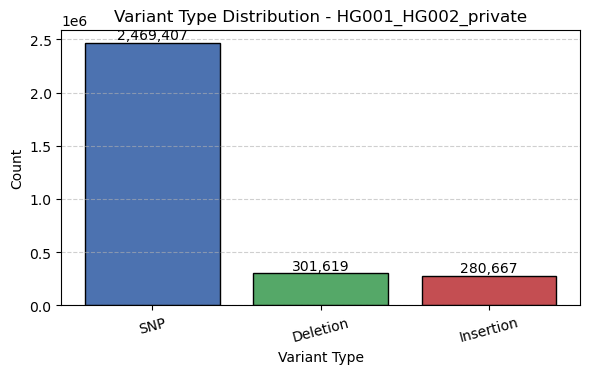

In [7]:
plot_variant_types_single(df, sample_name="HG001_HG002_private", plot_type="bar")

In [18]:
df1=pd.read_csv("/mnt/genomics/Vinisha/WGS/data/GIAB/bcftools/compare_vcf_HG001_HG002/sites_with_type.txt",sep="\t", names=["CHROM","POS","REF","ALT","GT","vartype","varlen"])

In [50]:
df1[df1["POS"]==2824891]

,CHROM,POS,REF,ALT,GT,vartype,varlen
1804,chr1,2824891,AGTGT,A,10,DEL,4
1805,chr1,2824891,AGTGTGTGTGTGT,A,10,DEL,12
1806,chr1,2824891,AGT,A,1,DEL,2
1807,chr1,2824891,AGTGTGT,A,1,DEL,6


In [51]:
HG001[HG001["POS"]==2824891]

,CHROM,POS,REF,ALT,QUAL,FILTER,GT,INFO,FORMAT
2182,chr1,2824891,AGTGTGTGTGTGT,"AGTGTGTGT,A",50.0,PASS,2/1,"{'platforms': 2, 'platformnames': 'Illumina,Pa...","{'DP': '209', 'ADALL': '28,48,60', 'AD': '0,27..."


In [52]:
HG002[HG002["POS"]==2824891]

,CHROM,POS,REF,ALT,QUAL,FILTER,GT,INFO,FORMAT
2579,chr1,2824891,AGTGTGT,"AGTGT,A",50.0,PASS,2/1,"{'platforms': 2, 'platformnames': 'Illumina,Pa...","{'DP': '204', 'ADALL': '0,24,28', 'AD': '10,37..."


In [45]:
HG001[HG001["ALT"].str.contains(",")][1:20]

,CHROM,POS,REF,ALT,QUAL,FILTER,GT,INFO,FORMAT
617,chr1,1265603,T,"TTG,TTGTG",50.0,PASS,1/2,"{'platforms': 2, 'platformnames': 'Illumina,Pa...","{'DP': '170', 'ADALL': '19,43,47', 'AD': '5,23..."
966,chr1,1667424,T,"TAAAATA,TAAATA",50.0,PASS,2/1,"{'platforms': 3, 'platformnames': 'PacBio,Illu...","{'DP': '570', 'ADALL': '0,130,104', 'AD': '8,3..."
1326,chr1,1876492,C,"CGAGAGAGA,CGAGAGAGAGAGAGA",50.0,PASS,1/2,"{'platforms': 2, 'platformnames': 'Illumina,Pa...","{'DP': '424', 'ADALL': '0,71,70', 'AD': '10,92..."
1341,chr1,1896396,CTT,"CT,C",50.0,PASS,2/1,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '479', 'ADALL': '18,122,136', 'AD': '1,..."
1352,chr1,1904424,A,"AAAATAAAT,AAAATAAATAAAT",50.0,PASS,1/2,"{'platforms': 2, 'platformnames': 'Illumina,Pa...","{'DP': '512', 'ADALL': '0,112,91', 'AD': '9,13..."
1862,chr1,2363762,C,"CAAA,CAAAAA",50.0,PASS,1/2,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '261', 'ADALL': '16,97,78', 'AD': '0,77..."
1961,chr1,2416398,G,"GCGACA,GGGACA",50.0,PASS,1/2,"{'platforms': 4, 'platformnames': 'Illumina,Pa...","{'DP': '612', 'ADALL': '0,108,117', 'AD': '20,..."
2170,chr1,2609034,TACAC,"TACACACAC,T",50.0,PASS,2/1,"{'platforms': 2, 'platformnames': 'Illumina,Pa...","{'DP': '280', 'ADALL': '0,28,58', 'AD': '6,44,..."
2182,chr1,2824891,AGTGTGTGTGTGT,"AGTGTGTGT,A",50.0,PASS,2/1,"{'platforms': 2, 'platformnames': 'Illumina,Pa...","{'DP': '209', 'ADALL': '28,48,60', 'AD': '0,27..."
2440,chr1,3000609,TAA,"TAAA,T",50.0,PASS,2/1,"{'platforms': 4, 'platformnames': 'Illumina,Pa...","{'DP': '334', 'ADALL': '25,71,79', 'AD': '2,41..."


In [22]:
# Create tuple identifiers for comparison
keys1 = set(df1[["CHROM", "POS", "REF", "ALT"]].itertuples(index=False, name=None))
keys2 = set(df[["CHROM", "POS", "REF", "ALT"]].itertuples(index=False, name=None))

# Symmetric difference = present in one but not both
unique_keys = keys1.symmetric_difference(keys2)

# Combine both dfs and filter for those unique variants
combined = pd.concat([df1, df], ignore_index=True)
unique_df = combined[combined[["CHROM", "POS", "REF", "ALT"]].apply(tuple, axis=1).isin(unique_keys)]

In [23]:
df["POS"]==

,CHROM,POS,REF,ALT,GT,vartype,varlen,QUAL,FILTER,INFO,FORMAT,VariantType,VariantLength
619,chr1,1769969,CAAAACA,C,1,DEL,6.0,NaN,NaN,NaN,NaN,NaN,NaN
677,chr1,1818305,T,TA,1,INS,1.0,NaN,NaN,NaN,NaN,NaN,NaN
719,chr1,1861110,C,CA,1,INS,1.0,NaN,NaN,NaN,NaN,NaN,NaN
757,chr1,1896396,CT,C,10,DEL,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1345,chr1,2246853,T,TG,1,INS,1.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6080820,chr22,50002495,CT,CTT,0/1,NaN,NaN,50.0,PASS,"{'platforms': 2, 'platformnames': 'Illumina,Pa...","{'DP': '285', 'ADALL': '10,48,76', 'AD': '3,39...",Insertion,1.0
6080879,chr22,50027533,CAAA,CAAAA,0/1,NaN,NaN,50.0,PASS,"{'platforms': 2, 'platformnames': 'Illumina,Pa...","{'DP': '456', 'ADALL': '6,55,120', 'AD': '3,40...",Insertion,1.0
6080905,chr22,50116660,CTTT,CTTTTT,0/1,NaN,NaN,50.0,PASS,"{'platforms': 2, 'platformnames': 'Illumina,Pa...","{'DP': '298', 'ADALL': '7,33,83', 'AD': '1,18,...",Insertion,2.0
6080949,chr22,50195341,GC,GCC,0/1,NaN,NaN,50.0,PASS,"{'platforms': 4, 'platformnames': 'Illumina,Pa...","{'DP': '889', 'ADALL': '25,211,187', 'AD': '5,...",Insertion,1.0


In [24]:
df[df["POS"]==1769969]

,CHROM,POS,REF,ALT,QUAL,FILTER,GT,INFO,FORMAT,VariantType,VariantLength
1447324,chr1,1769969,CAAAACAAAAACA,CAAAACA,50.0,PASS,0/1,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '657', 'ADALL': '13,130,129', 'AD': '8,...",Deletion,6
1447325,chr1,1769969,CAAAACAAAAACA,C,50.0,PASS,1/0,"{'platforms': 3, 'platformnames': 'Illumina,Pa...","{'DP': '657', 'ADALL': '13,130,129', 'AD': '8,...",Deletion,12


In [25]:
df1[df1["POS"]==1769969]

,CHROM,POS,REF,ALT,GT,vartype,varlen
619,chr1,1769969,CAAAACA,C,1,DEL,6
620,chr1,1769969,CAAAACAAAAACA,C,1,DEL,12


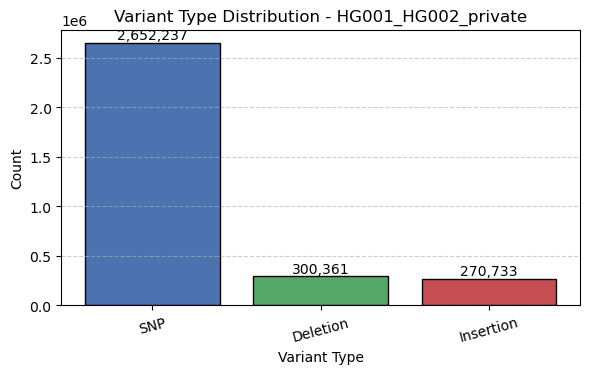

In [15]:
plot_variant_types_single(HG001_HG005_private, sample_name="HG001_HG002_private", plot_type="bar")

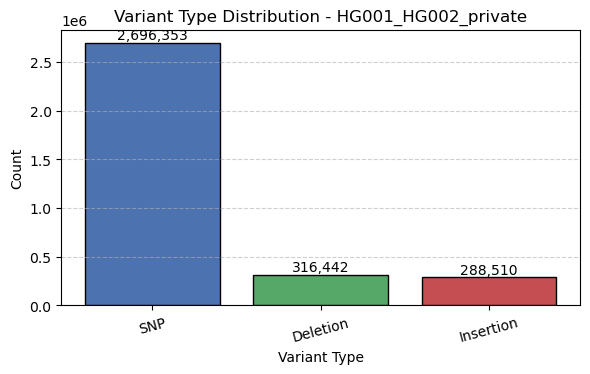

In [16]:
plot_variant_types_single(HG002_HG005_private, sample_name="HG001_HG002_private", plot_type="bar")

In [18]:
import pandas as pd

def summarize_indel_lengths(df):
    """
    Summarize how many insertions and deletions fall into specific length bins.
    Expects columns: 'VariantType' and 'VariantLength'
    """

    if not {"VariantType", "VariantLength"}.issubset(df.columns):
        raise ValueError("DataFrame must contain 'VariantType' and 'VariantLength' columns.")

    # Filter insertions and deletions
    indels = df[df["VariantType"].isin(["Insertion", "Deletion"])].copy()
    indels["VariantLength"] = pd.to_numeric(indels["VariantLength"], errors="coerce")
    indels = indels.dropna(subset=["VariantLength"])

    # Define bins and labels
    bins = [0, 10, 20, 50,  100, 500, 1000, 5000, float("inf")]
    labels = ["1–10","11-20","21-50","51–100", "101–500", "501–1000", "1001–5000", ">5000"]

    # Bin the data
    indels["LengthRange"] = pd.cut(indels["VariantLength"], bins=bins, labels=labels, right=True)

    # Count per type and bin
    summary = (
        indels.groupby(["VariantType", "LengthRange"])
        .size()
        .unstack(fill_value=0)
        .astype(int)
    )

    # Add total per type
    summary["Total"] = summary.sum(axis=1)

    return summary


In [22]:
summary = summarize_indel_lengths(HG001_HG002_private)
summary

/tmp/ipykernel_27531/1466262226.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["VariantType", "LengthRange"])


LengthRange,1–10,11-20,21-50,51–100,101–500,501–1000,1001–5000,>5000,Total
VariantType,,,,,,,,,
Deletion,277962,17935,5650,38,24,4,5,1,301619
Insertion,259525,15736,5224,89,66,9,18,0,280667


In [23]:
summary = summarize_indel_lengths(HG001_HG005_private)
summary

/tmp/ipykernel_27531/1466262226.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["VariantType", "LengthRange"])


LengthRange,1–10,11-20,21-50,51–100,101–500,501–1000,1001–5000,>5000,Total
VariantType,,,,,,,,,
Deletion,277713,17294,5275,29,39,3,8,0,300361
Insertion,250686,15159,4762,43,49,8,25,1,270733


In [24]:
summary = summarize_indel_lengths(HG002_HG005_private)
summary

/tmp/ipykernel_27531/1466262226.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["VariantType", "LengthRange"])


LengthRange,1–10,11-20,21-50,51–100,101–500,501–1000,1001–5000,>5000,Total
VariantType,,,,,,,,,
Deletion,292123,18385,5859,27,35,5,7,1,316442
Insertion,266865,16021,5422,98,71,15,17,1,288510


In [22]:
common = pd.merge(
    HG001[["CHROM", "POS", "REF", "ALT"]],
    HG002[["CHROM", "POS", "REF", "ALT"]],
    on=["CHROM", "POS", "REF"],
    suffixes=("_HG001", "_HG002")
)
 
# Keep only rows where ALT differs
diff_alt = common[common["ALT_HG001"] != common["ALT_HG002"]].reset_index(drop=True)

# Show results
print(f"Variants with same CHROM, POS, REF but different ALT: {len(diff_alt)}")
diff_alt.head()

Variants with same CHROM, POS, REF but different ALT: 36468


,CHROM,POS,REF,ALT_HG001,ALT_HG002
0,chr1,1265603,T,"TTG,TTGTG",TTGTG
1,chr1,1667424,T,"TAAAATA,TAAATA",TAAATA
2,chr1,1866635,T,TA,"TA,TAAA"
3,chr1,1876492,C,"CGAGAGAGA,CGAGAGAGAGAGAGA",CGA
4,chr1,1881428,C,T,CT


In [23]:
diff_alt

,CHROM,POS,REF,ALT_HG001,ALT_HG002
0,chr1,1265603,T,"TTG,TTGTG",TTGTG
1,chr1,1667424,T,"TAAAATA,TAAATA",TAAATA
2,chr1,1866635,T,TA,"TA,TAAA"
3,chr1,1876492,C,"CGAGAGAGA,CGAGAGAGAGAGAGA",CGA
4,chr1,1881428,C,T,CT
...,...,...,...,...,...
36463,chr22,50204620,CAAA,C,"CAA,C"
36464,chr22,50296193,T,"TAC,TACAC",TACAC
36465,chr22,50565797,CTTT,"CTT,C",C
36466,chr22,50724422,C,G,T


In [26]:
###Using bash commands to normalize
bgzip M1a_decomposed.vcf
tabix -p vcf M1a_decomposed.vcf.gz



In [28]:
import os
import glob
import subprocess

# --- Settings ---
work_dir = "/mnt/genomics/Vinisha/WGS/data/In_house_GIAB"
reference = "/mnt/genomics/data/Resources/ReferenceGenomes/hg38-alt_masked.graph.cnv.hla.rna_v4/genome.fa"

# --- Move into the working directory ---
os.chdir(work_dir)

# --- Find all hard-filtered VCFs recursively ---
vcfs = glob.glob("**/*hard-filtered.vcf.gz", recursive=True)
print(f"Found {len(vcfs)} VCF files")

# --- Loop through and normalize each VCF ---
for vcf in vcfs:
    base = os.path.basename(vcf).replace(".hard-filtered.vcf.gz", "")
    print(f"\n🧬 Processing: {base}")

    # Step 1: Split multi-allelic variants
    split_vcf = f"{base}_split_multiallelic.vcf.gz"
    cmd1 = ["bcftools", "norm", "-m", "-any", vcf, "-Oz", "-o", split_vcf]
    subprocess.run(cmd1, check=True)

    # Step 2: Normalize and decompose with reference
    decomposed_vcf = f"{base}_decomposed.vcf.gz"
    cmd2 = [
        "bcftools", "norm", "-a", "--atom-overlaps", ".",
        "-f", reference,
        "-Oz", "-o", decomposed_vcf,
        split_vcf
    ]
    subprocess.run(cmd2, check=True)

    # Step 3: Index the decomposed VCF
    subprocess.run(["bcftools", "index", decomposed_vcf], check=True)

    print(f"✅ Finished: {base}")


SyntaxError: invalid syntax (2947683710.py, line 1)

In [53]:
import os
import glob
import subprocess

# --- Settings ---
work_dir = "/mnt/genomics/Vinisha/WGS/data/GIAB"
reference = "/mnt/genomics/data/Resources/ReferenceGenomes/hg38-alt_masked.graph.cnv.hla.rna_v4/genome.fa"

# --- Move into the working directory ---
os.chdir(work_dir)

# --- Find all hard-filtered VCFs recursively ---
vcfs = glob.glob("**/*_GRCh38_1_22_v4.2.1_benchmark.vcf.gz", recursive=True)
print(f"Found {len(vcfs)} VCF files")

# --- Loop through and normalize each VCF ---
for vcf in vcfs:
    base = os.path.basename(vcf).replace("_GRCh38_1_22_v4.2.1_benchmark.vcf.gz", "")
    print(f"\n🧬 Processing: {base}")

    # Step 1: Split multi-allelic variants
    split_vcf = f"{base}_split_multiallelic.vcf.gz"
    cmd1 = ["bcftools", "norm", "-m", "-any", vcf, "-Oz", "-o", split_vcf]
    subprocess.run(cmd1, check=True)

    # Step 2: Normalize and decompose with reference
    decomposed_vcf = f"{base}_decomposed.vcf.gz"
    cmd2 = [
        "bcftools", "norm", "-a", "--atom-overlaps", ".",
        "-f", reference,
        "-Oz", "-o", decomposed_vcf,
        split_vcf
    ]
    subprocess.run(cmd2, check=True)

    # Step 3: Index the decomposed VCF
    subprocess.run(["bcftools", "index", decomposed_vcf], check=True)

    print(f"✅ Finished: {base}")


Found 3 VCF files

🧬 Processing: HG001


Lines   total/split/joined/realigned/skipped:	3893341/42393/0/0/0
Lines   total/split/joined/realigned/skipped:	3935734/0/0/26880/0


✅ Finished: HG001

🧬 Processing: HG002


Lines   total/split/joined/realigned/skipped:	4048342/47781/0/0/0
Lines   total/split/joined/realigned/skipped:	4096123/0/0/29915/0


✅ Finished: HG002

🧬 Processing: HG005


Lines   total/split/joined/realigned/skipped:	3856856/30954/0/0/0
Lines   total/split/joined/realigned/skipped:	3887810/0/0/18624/0


✅ Finished: HG005


In [ ]:
bcftools isec -p compare_vcf_HG001_HG002 -n=1 HG001_decomposed.vcf.gz HG002_decomposed.vcf.gz
bcftools isec -p compare_vcf_HG001_HG005 -n=1 HG001_decomposed.vcf.gz HG005_decomposed.vcf.gz
bcftools isec -p compare_vcf_HG002_HG005 -n=1 HG002_decomposed.vcf.gz HG005_decomposed.vcf.gz

In [ ]:
bcftools isec -p compare_vcf_NA12878_NA24385 -n=1 WGS_Pilot2-NA12878_decomposed.vcf.gz WGS_Pilot2-NA24385_decomposed.vcf.gz
bcftools isec -p compare_vcf_NA12878_NA24631 -n=1 WGS_Pilot2-NA12878_decomposed.vcf.gz WGS_Pilot2-NA24631_decomposed.vcf.gz
bcftools isec -p compare_vcf_NA24385_NA24631 -n=1 WGS_Pilot2-NA24385_decomposed.vcf.gz WGS_Pilot2-NA24631_decomposed.vcf.gz

In [54]:
from cyvcf2 import VCF
import pandas as pd
from pathlib import Path

# Base directories to search
base_dirs = [
    Path("/mnt/genomics/Vinisha/WGS/data/GIAB/"),
    Path("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB"),
]

for base_dir in base_dirs:
    for vcf_file in base_dir.glob("compare_vcf_*/000[01].vcf"):
        print(vcf_file)
        vcf = VCF(str(vcf_file))
        records = []

        for var in vcf:
            ref = var.REF
            alt = var.ALT[0] if var.ALT else "."

            # Determine variant type
            if len(ref) == 1 and len(alt) == 1:
                vartype = "SNP"
            elif len(alt) > len(ref):
                vartype = "INS"
            elif len(alt) < len(ref):
                vartype = "DEL"
            else:
                vartype = "COMPLEX"

            # Variant length (always positive)
            varlen = abs(len(alt) - len(ref))

            # Get GT as string
            gt = var.genotypes[0][:2] if var.genotypes else [0, 0]
            gt_str = "/".join(map(str, gt))

            records.append({
                "CHROM": var.CHROM,
                "POS": var.POS,
                "REF": ref,
                "ALT": alt,
                "GT": gt_str,
                "Variant_Type": vartype,
                "Variant_Length": varlen
            })

        df = pd.DataFrame(records)

        # Parse folder name to get sample names
        folder_name = vcf_file.parent.name  # e.g., compare_vcf_HG002_HG005
        first_id, second_id = folder_name.replace("compare_vcf_", "").split("_")

        # Decide output name
        if vcf_file.name == "0000.vcf":
            out_csv = base_dir / f"{first_id}_unique_to_{second_id}.csv"
        else:  # 0001.vcf
            out_csv = base_dir / f"{second_id}_unique_to_{first_id}.csv"

        df.to_csv(out_csv, index=False)
        print(f"✅ Written {out_csv} with {len(df)} variants")


/mnt/genomics/Vinisha/WGS/data/GIAB/compare_vcf_HG002_HG005/0000.vcf
✅ Written /mnt/genomics/Vinisha/WGS/data/GIAB/HG002_unique_to_HG005.csv with 1745203 variants
/mnt/genomics/Vinisha/WGS/data/GIAB/compare_vcf_HG002_HG005/0001.vcf
✅ Written /mnt/genomics/Vinisha/WGS/data/GIAB/HG005_unique_to_HG002.csv with 1536883 variants
/mnt/genomics/Vinisha/WGS/data/GIAB/compare_vcf_HG001_HG005/0000.vcf
✅ Written /mnt/genomics/Vinisha/WGS/data/GIAB/HG001_unique_to_HG005.csv with 1626759 variants
/mnt/genomics/Vinisha/WGS/data/GIAB/compare_vcf_HG001_HG005/0001.vcf
✅ Written /mnt/genomics/Vinisha/WGS/data/GIAB/HG005_unique_to_HG001.csv with 1578782 variants
/mnt/genomics/Vinisha/WGS/data/GIAB/compare_vcf_HG001_HG002/0000.vcf
✅ Written /mnt/genomics/Vinisha/WGS/data/GIAB/HG001_unique_to_HG002.csv with 1434610 variants
/mnt/genomics/Vinisha/WGS/data/GIAB/compare_vcf_HG001_HG002/0001.vcf
✅ Written /mnt/genomics/Vinisha/WGS/data/GIAB/HG002_unique_to_HG001.csv with 1594953 variants
/mnt/genomics/Vinisha/

In [51]:
len(HG001_unique_to_HG002)

1434610

In [46]:
HG001_unique_to_HG002["GT"] = (HG001_unique_to_HG002["GT"].str.replace("-1", "1", regex=False))
# Heterozygous: one ref (0) and one alt (1)
HG001_unique_to_HG002_het = HG001_unique_to_HG002[HG001_unique_to_HG002["GT"].isin(["0/1", "1/0"])].copy()
# Homozygous: both same and non-missing (1/1 or 0/0)
HG001_unique_to_HG002_hom = HG001_unique_to_HG002[HG001_unique_to_HG002["GT"].isin(["1/1", "0/0"])].copy()

In [12]:
# List of all DataFrame names
dfs = [
    "HG001_unique_to_HG002",
    "HG002_unique_to_HG001",
    "HG002_unique_to_HG005",
    "HG005_unique_to_HG002"
]

# Loop through each DataFrame name dynamically
for name in dfs:
    df = globals()[name]
    
    # Replace -1 with 1 in GT
    df["GT"] = df["GT"].str.replace("-1", "1", regex=False)
    
    # Filter heterozygous variants
    globals()[f"{name}_het"] = df[df["GT"].isin(["0/1", "1/0"])].copy()
    
    # Filter homozygous variants
    globals()[f"{name}_hom"] = df[df["GT"].isin(["1/1", "0/0"])].copy()


In [1]:
import pandas as pd
from pathlib import Path

# Base folders where the CSVs were written
csv_dirs = [
    Path("/mnt/genomics/Vinisha/WGS/data/GIAB"),
    Path("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB"),
]

# Dictionary to store all DataFrames
unique_variants = {}

for csv_dir in csv_dirs:
    for csv_file in csv_dir.glob("*.csv"):
        name = csv_file.stem  # e.g., HG002_unique_to_HG005
        df = pd.read_csv(csv_file)
        unique_variants[name] = df
        print(f"✅ Loaded {name}: {df.shape[0]} variants, {df.shape[1]} columns")

# Optionally, access them directly:
HG002_unique_to_HG005 = unique_variants["HG002_unique_to_HG005"]
HG005_unique_to_HG002 = unique_variants["HG005_unique_to_HG002"]
HG001_unique_to_HG005 = unique_variants["HG001_unique_to_HG005"]
HG005_unique_to_HG001 = unique_variants["HG005_unique_to_HG001"]
HG001_unique_to_HG002 = unique_variants["HG001_unique_to_HG002"]
HG002_unique_to_HG001 = unique_variants["HG002_unique_to_HG001"]
NA24385_unique_to_NA24631 = unique_variants["NA24385_unique_to_NA24631"]
NA24631_unique_to_NA24385 = unique_variants["NA24631_unique_to_NA24385"]
NA12878_unique_to_NA24385 = unique_variants["NA12878_unique_to_NA24385"]
NA24385_unique_to_NA12878 = unique_variants["NA24385_unique_to_NA12878"]
NA12878_unique_to_NA24631 = unique_variants["NA12878_unique_to_NA24631"]
NA24631_unique_to_NA12878 = unique_variants["NA24631_unique_to_NA12878"]

print("\n🎉 All CSVs successfully loaded into variables and dictionary!")


✅ Loaded HG005_unique_to_HG002: 1536883 variants, 7 columns
✅ Loaded HG001_unique_to_HG002: 1434610 variants, 7 columns
✅ Loaded HG002_unique_to_HG001: 1594953 variants, 7 columns
✅ Loaded HG001_unique_to_HG005: 1626759 variants, 7 columns
✅ Loaded HG005_unique_to_HG001: 1578782 variants, 7 columns
✅ Loaded HG002_unique_to_HG005: 1745203 variants, 7 columns
✅ Loaded M1a_decomposed_short: 6665702 variants, 1 columns
✅ Loaded NA12878_unique_to_NA24631: 2125725 variants, 7 columns
✅ Loaded NA24385_unique_to_NA24631: 2109775 variants, 7 columns
✅ Loaded M2b_decomposed_short: 6340323 variants, 1 columns
✅ Loaded M2c_decomposed_short: 5963978 variants, 1 columns
✅ Loaded NA12878_unique_to_NA24385: 1925145 variants, 7 columns
✅ Loaded M2a_decomposed_short: 6784256 variants, 1 columns
✅ Loaded NA24631_unique_to_NA24385: 2059870 variants, 7 columns
✅ Loaded NA24385_unique_to_NA12878: 1935782 variants, 7 columns
✅ Loaded M1c_decomposed_short: 5760706 variants, 1 columns
✅ Loaded M1b_decomposed_s

In [11]:
import matplotlib.pyplot as plt

def plot_variant_types_multi(dfs, sample_names, plot_type="bar"):
    """
    Plot variant type distributions for multiple VCF comparison DataFrames
    using consistent color and style.

    Parameters
    ----------
    dfs : list of pd.DataFrame
        Each DataFrame must contain a column named 'Variant_Type'
    sample_names : list of str
        Names of the samples for labeling (same order as dfs)
    plot_type : str, default='bar'
        Type of plot: 'bar' or 'pie'
    """
    if len(dfs) != len(sample_names):
        raise ValueError("Length of dfs and sample_names must be the same.")

    n = len(dfs)
    cols = 3  # number of columns in the figure
    rows = (n + cols - 1) // cols  # number of rows needed

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
    axes = axes.flatten()

    colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]  # consistent palette

    for i, (df, name) in enumerate(zip(dfs, sample_names)):
        if "Variant_Type" not in df.columns:
            raise ValueError(f"DataFrame for {name} must contain 'Variant_Type' column.")

        counts = df["Variant_Type"].value_counts()

        if plot_type == "pie":
            axes[i].pie(
                counts.values,
                labels=counts.index,
                autopct="%1.1f%%",
                startangle=90,
                colors=colors[:len(counts)],
                wedgeprops={"edgecolor": "black"}
            )
            axes[i].set_title(f"{name}", fontsize=12)
        else:  # bar plot
            bars = axes[i].bar(
                counts.index,
                counts.values,
                color=colors[:len(counts)],
                edgecolor="black"
            )
            axes[i].set_title(f"{name}", fontsize=12)
            axes[i].set_xlabel("Variant Type")
            axes[i].set_ylabel("Count")
            axes[i].grid(axis="y", linestyle="--", alpha=0.6)
            axes[i].tick_params(axis="x", rotation=15)

            # Add value labels on bars
            for bar in bars:
                axes[i].text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f"{int(bar.get_height()):,}",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# --- GIAB comparisons ---
giab_dfs = [
    unique_variants["HG002_unique_to_HG005"],
    unique_variants["HG001_unique_to_HG005"],
    unique_variants["HG001_unique_to_HG002"],
    unique_variants["HG005_unique_to_HG001"],
    unique_variants["HG005_unique_to_HG002"],
    unique_variants["HG002_unique_to_HG001"],
]

giab_names = [
    "HG002_unique_to_HG005",
    "HG001_unique_to_HG005",
    "HG001_unique_to_HG002",
    "HG005_unique_to_HG001",
    "HG005_unique_to_HG002",
    "HG002_unique_to_HG001",
]

plot_variant_types_multi(giab_dfs, giab_names, plot_type="bar")


# --- In-house GIAB comparisons ---
inh_dfs = [
    unique_variants["NA12878_unique_to_NA24631"],
    unique_variants["NA24385_unique_to_NA24631"],
    unique_variants["NA12878_unique_to_NA24385"],
    unique_variants["NA24631_unique_to_NA24385"],
    unique_variants["NA24385_unique_to_NA12878"],
    unique_variants["NA24631_unique_to_NA12878"],
]

inh_names = [
    "NA12878_unique_to_NA24631",
    "NA24385_unique_to_NA24631",
    "NA12878_unique_to_NA24385",
    "NA24631_unique_to_NA24385",
    "NA24385_unique_to_NA12878",
    "NA24631_unique_to_NA12878",
]

plot_variant_types_multi(inh_dfs, inh_names, plot_type="bar")


NameError: name 'unique_variants' is not defined

In [57]:
import pandas as pd

def summarize_indel_lengths(df):
    """
    Summarize how many insertions and deletions fall into specific length bins.
    Expects columns: 'Variant_Type' and 'Variant_Length'
    """
    if not {"Variant_Type", "Variant_Length"}.issubset(df.columns):
        raise ValueError("DataFrame must contain 'Variant_Type' and 'Variant_Length' columns.")

    # Filter for insertions and deletions only
    indels = df[df["Variant_Type"].isin(["INS", "DEL"])].copy()
    indels["Variant_Length"] = pd.to_numeric(indels["Variant_Length"], errors="coerce")
    indels = indels.dropna(subset=["Variant_Length"])

    # Define length bins
    bins = [0, 10, 20, 50, 100, 500, 1000, 5000, float("inf")]
    labels = ["1–10", "11–20", "21–50", "51–100", "101–500", "501–1000", "1001–5000", ">5000"]

    # Bin the variant lengths
    indels["LengthRange"] = pd.cut(indels["Variant_Length"], bins=bins, labels=labels, right=True)

    # Count number of variants per type and range
    summary = (
        indels.groupby(["Variant_Type", "LengthRange"])
        .size()
        .unstack(fill_value=0)
        .astype(int)
    )

    # Add total count per type
    summary["Total"] = summary.sum(axis=1)

    return summary


# ✅ Run the summary for all DataFrames in your dictionary
summaries = {}

for name, df in unique_variants.items():
    print(f"Processing {name} ...")
    summary_df = summarize_indel_lengths(df)
    summaries[name] = summary_df
    print(summary_df, "\n")

print("✅ All summaries generated and stored in 'summaries' dictionary.")


Processing HG005_unique_to_HG002 ...
LengthRange     1–10  11–20  21–50  51–100  101–500  501–1000  1001–5000  \
Variant_Type                                                               
DEL           107981   7653   2512       7       19         3          5   
INS            99270   7261   2442      23       22         6         11   

LengthRange   >5000   Total  
Variant_Type                 
DEL               0  118180  
INS               1  109036   

Processing HG001_unique_to_HG002 ...


/tmp/ipykernel_31692/2897139414.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["Variant_Type", "LengthRange"])
/tmp/ipykernel_31692/2897139414.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["Variant_Type", "LengthRange"])


LengthRange     1–10  11–20  21–50  51–100  101–500  501–1000  1001–5000  \
Variant_Type                                                               
DEL           119982   7599   2243      17       13         2          3   
INS           113015   6999   1982      16       16         1         11   

LengthRange   >5000   Total  
Variant_Type                 
DEL               0  129859  
INS               0  122040   

Processing HG002_unique_to_HG001 ...
LengthRange     1–10  11–20  21–50  51–100  101–500  501–1000  1001–5000  \
Variant_Type                                                               
DEL           144834   9956   3361      21       11         2          2   
INS           138038   8547   3232      73       50         8          7   

LengthRange   >5000   Total  
Variant_Type                 
DEL               1  158188  
INS               0  149955   

Processing HG001_unique_to_HG005 ...


/tmp/ipykernel_31692/2897139414.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["Variant_Type", "LengthRange"])
/tmp/ipykernel_31692/2897139414.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["Variant_Type", "LengthRange"])


LengthRange     1–10  11–20  21–50  51–100  101–500  501–1000  1001–5000  \
Variant_Type                                                               
DEL           155238   8633   2451      19       18         1          3   
INS           141071   7400   2019      19       21         2         12   

LengthRange   >5000   Total  
Variant_Type                 
DEL               0  166363  
INS               0  150544   

Processing HG005_unique_to_HG001 ...
LengthRange     1–10  11–20  21–50  51–100  101–500  501–1000  1001–5000  \
Variant_Type                                                               
DEL           113419   8331   2784      10       21         2          5   
INS           103831   7599   2733      24       28         6         13   

LengthRange   >5000   Total  
Variant_Type                 
DEL               0  124572  
INS               1  114235   

Processing HG002_unique_to_HG005 ...


...

LengthRange     1–10  11–20  21–50  51–100  101–500  501–1000  1001–5000  \
Variant_Type                                                               
DEL           225926  18357   7596     520        0         0          0   
INS           233608  19970   9384    1404        0         0          0   

LengthRange   >5000   Total  
Variant_Type                 
DEL               0  252399  
INS               0  264366   

Processing NA12878_unique_to_NA24385 ...
LengthRange     1–10  11–20  21–50  51–100  101–500  501–1000  1001–5000  \
Variant_Type                                                               
DEL           206258  16702   7092     445        0         0          0   
INS           214101  18757   8540    1281        0         0          0   

LengthRange   >5000   Total  
Variant_Type                 
DEL               0  230497  
INS               0  242679   

Processing NA24631_unique_to_NA24385 ...


/tmp/ipykernel_31692/2897139414.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["Variant_Type", "LengthRange"])
/tmp/ipykernel_31692/2897139414.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["Variant_Type", "LengthRange"])


LengthRange     1–10  11–20  21–50  51–100  101–500  501–1000  1001–5000  \
Variant_Type                                                               
DEL           219250  17464   7313     434        0         0          0   
INS           229028  19600   8695    1312        2         0          0   

LengthRange   >5000   Total  
Variant_Type                 
DEL               0  244461  
INS               0  258637   

Processing NA24385_unique_to_NA12878 ...
LengthRange     1–10  11–20  21–50  51–100  101–500  501–1000  1001–5000  \
Variant_Type                                                               
DEL           206830  16869   7107     499        0         0          0   
INS           216080  19171   8990    1322        0         0          0   

LengthRange   >5000   Total  
Variant_Type                 
DEL               0  231305  
INS               0  245563   

Processing NA24631_unique_to_NA12878 ...


/tmp/ipykernel_31692/2897139414.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["Variant_Type", "LengthRange"])
/tmp/ipykernel_31692/2897139414.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["Variant_Type", "LengthRange"])


LengthRange     1–10  11–20  21–50  51–100  101–500  501–1000  1001–5000  \
Variant_Type                                                               
DEL           221006  17474   7387     466        0         0          0   
INS           230776  19750   8729    1333        2         0          0   

LengthRange   >5000   Total  
Variant_Type                 
DEL               0  246333  
INS               0  260590   

✅ All summaries generated and stored in 'summaries' dictionary.


In [60]:
import pandas as pd

# Combine all summaries into one master table
combined_summary = []

for name, summary_df in summaries.items():
    # Add a column with the sample comparison name
    temp = summary_df.copy()
    temp.insert(0, "Comparison", name)
    # Flatten MultiIndex if needed
    temp = temp.reset_index()
    combined_summary.append(temp)

# Concatenate all summaries together
combined_summary = pd.concat(combined_summary, ignore_index=True)

# Reorder columns for clarity
columns_order = ["Comparison", "Variant_Type", "1–10", "11–20", "21–50", "51–100",
                 "101–500", "501–1000", "1001–5000", ">5000", "Total"]
combined_summary = combined_summary.reindex(columns=columns_order)

# Display table
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
print(combined_summary)

# Optionally save to CSV
combined_summary.to_csv("Indel_Length_Summary_All.csv", index=False)
print("\n✅ Saved combined indel summary table: Indel_Length_Summary_All.csv")


LengthRange                 Comparison Variant_Type    1–10  11–20  21–50  \
0                HG005_unique_to_HG002          DEL  107981   7653   2512   
1                HG005_unique_to_HG002          INS   99270   7261   2442   
2                HG001_unique_to_HG002          DEL  119982   7599   2243   
3                HG001_unique_to_HG002          INS  113015   6999   1982   
4                HG002_unique_to_HG001          DEL  144834   9956   3361   
..                                 ...          ...     ...    ...    ...   
19           NA24631_unique_to_NA24385          INS  229028  19600   8695   
20           NA24385_unique_to_NA12878          DEL  206830  16869   7107   
21           NA24385_unique_to_NA12878          INS  216080  19171   8990   
22           NA24631_unique_to_NA12878          DEL  221006  17474   7387   
23           NA24631_unique_to_NA12878          INS  230776  19750   8729   

LengthRange  51–100  101–500  501–1000  1001–5000  >5000   Total  
0       

In [62]:
# Optionally save to CSV
combined_summary.to_csv("Indel_Length_Summary_All.csv", index=False)
print("\n✅ Saved combined indel summary table: Indel_Length_Summary_All.csv")


✅ Saved combined indel summary table: Indel_Length_Summary_All.csv


In [ ]:
# Compress and index all 0000.vcf and 0001.vcf files under your current directory
find ./GIAB ./In_house_GIAB -type f \( -name "0000.vcf" -o -name "0001.vcf" \) | while read file; do
    echo "Processing $file ..."

    # Compress the file with bgzip
    bgzip -c "$file" > "${file}.gz"

    # Index the compressed VCF with tabix
    tabix -p vcf "${file}.gz"

    echo "Created: ${file}.gz and ${file}.gz.tbi"
done

In [141]:
HG001_unique_to_HG002

,CHROM,POS,REF,ALT,GT,Variant_Type,Variant_Length
0,chr1,797392,G,A,0/1,SNP,0
1,chr1,805514,AC,A,0/1,DEL,1
2,chr1,807445,A,G,0/1,SNP,0
3,chr1,807641,T,C,0/1,SNP,0
4,chr1,814264,T,C,1/1,SNP,0
...,...,...,...,...,...,...,...
1434617,chr22,50791067,C,T,0/1,SNP,0
1434618,chr22,50791178,A,T,0/1,SNP,0
1434619,chr22,50791190,G,A,0/1,SNP,0
1434620,chr22,50792591,T,C,0/1,SNP,0


In [2]:
import pandas as pd

def vcf_to_dataframe(vcf_file):
    """
    Convert a VCF file to a pandas DataFrame.

    Parameters
    ----------
    vcf_file : str
        Path to a VCF file (can be gzipped with .gz)

    Returns
    -------
    df : pd.DataFrame
        DataFrame with columns:
        CHROM, POS, ID, REF, ALT, QUAL, FILTER, INFO (raw),
        plus parsed INFO fields and FORMAT/sample fields
    """
    # Open VCF (handle gzipped)
    import gzip
    open_func = gzip.open if vcf_file.endswith(".gz") else open

    rows = []
    with open_func(vcf_file, "rt") as f:
        for line in f:
            if line.startswith("#"):
                # Skip header lines
                continue
            parts = line.strip().split("\t")
            if len(parts) < 9:
                continue  # skip malformed lines

            chrom, pos, vid, ref, alt, qual, filt, info, fmt = parts[:9]
            sample = parts[9] if len(parts) > 9 else None

            # Parse INFO field into dict
            info_dict = {}
            for entry in info.split(";"):
                if "=" in entry:
                    k, v = entry.split("=", 1)
                    info_dict[k] = v
                else:
                    info_dict[entry] = True

            # Parse FORMAT/sample
            fmt_dict = {}
            if sample and fmt:
                fmt_keys = fmt.split(":")
                fmt_vals = sample.split(":")
                fmt_dict = dict(zip(fmt_keys, fmt_vals))

            row = {
                "CHROM": chrom,
                "POS": int(pos),
                "ID": vid,
                "REF": ref,
                "ALT": alt,
                "QUAL": float(qual) if qual != "." else None,
                "FILTER": filt,
                "INFO_raw": info,
                "FORMAT_raw": fmt,
            }

            # Merge parsed INFO and FORMAT fields
            row.update(info_dict)
            row.update(fmt_dict)

            rows.append(row)

    df = pd.DataFrame(rows)
    return df


In [5]:
import pandas as pd
import gzip

def vcf_to_dataframe_giab(vcf_file):
    """
    Convert a single-sample VCF file to a pandas DataFrame with minimal fields.

    Parameters
    ----------
    vcf_file : str
        Path to a VCF file (.vcf or .vcf.gz)

    Returns
    -------
    pd.DataFrame
        Columns: CHROM, POS, REF, ALT, GT
    """

    open_func = gzip.open if vcf_file.endswith(".gz") else open
    records = []

    with open_func(vcf_file, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue  # skip header

            parts = line.strip().split("\t")
            if len(parts) < 10:
                continue  # malformed line or missing genotype

            chrom = parts[0]
            pos = int(parts[1])
            ref = parts[3]
            alt = parts[4]

            # FORMAT and SAMPLE columns
            fmt = parts[8].split(":")
            sample_data = parts[9].split(":")
            fmt_dict = dict(zip(fmt, sample_data))

            # Extract GT if present
            gt = fmt_dict.get("GT", None)

            records.append({
                "CHROM": chrom,
                "POS": pos,
                "REF": ref,
                "ALT": alt,
                "GT": gt
            })

    return pd.DataFrame(records)

In [6]:
M1a_decomposed = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1a_decomposed.vcf")
M1b_decomposed = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1b_decomposed.vcf")
M1c_decomposed = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1c_decomposed.vcf")

In [ ]:
HG001=vcf_to_dataframe_giab("/mnt/genomics/Vinisha/WGS/data/GIAB/HG001_decomposed.vcf")

In [ ]:
HG002=vcf_to_dataframe_giab("/mnt/genomics/Vinisha/WGS/data/GIAB/HG002_decomposed.vcf")

In [ ]:
HG005=vcf_to_dataframe_giab("/mnt/genomics/Vinisha/WGS/data/GIAB/HG005_decomposed.vcf")

In [4]:
M2a_decomposed = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M2a_decomposed.vcf")
M2b_decomposed = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M2b_decomposed.vcf")
M2c_decomposed = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M2c_decomposed.vcf")

In [13]:
import pandas as pd

def get_unique_variants(df_query, df_reference):
    """
    Return variants unique to df_query compared to df_reference,
    based on CHROM, POS, REF, and ALT.

    Parameters
    ----------
    df_query : pd.DataFrame
        The sample for which you want unique variants (e.g., HG002)
    df_reference : pd.DataFrame
        The comparison sample (e.g., HG001)

    Returns
    -------
    pd.DataFrame
        Variants present only in df_query
    """
    # Create variant key
    df_query = df_query.copy()
    df_reference = df_reference.copy()

    df_query["VAR_KEY"] = (
        df_query["CHROM"].astype(str) + "_" +
        df_query["POS"].astype(str) + "_" +
        df_query["REF"] + "_" +
        df_query["ALT"]
    )

    df_reference["VAR_KEY"] = (
        df_reference["CHROM"].astype(str) + "_" +
        df_reference["POS"].astype(str) + "_" +
        df_reference["REF"] + "_" +
        df_reference["ALT"]
    )

    # Compute set difference
    ref_keys = set(df_reference["VAR_KEY"])
    unique_df = df_query[~df_query["VAR_KEY"].isin(ref_keys)].drop(columns=["VAR_KEY"])

    print(f"✅ Unique variants in HG002 (not in HG001): {len(unique_df):,}")
    return unique_df


In [15]:
HG002_unique = get_unique_variants(HG002, HG001)

✅ Unique variants in HG002 (not in HG001): 1,594,951
  CHROM     POS REF     ALT   GT
0  chr1  602113   T  TGCCCA  1/1
1  chr1  604358   G       C  1/1
2  chr1  604360   T       C  1/1
3  chr1  611317   A       G  1/1
4  chr1  631859  CG       C  1/1


In [9]:
M1a_mosaic_decomposed = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1a_mosaic_decomposed.vcf")
M1b_mosaic_decomposed = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1b_mosaic_decomposed.vcf")
M1c_mosaic_decomposed = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1c_mosaic_decomposed.vcf")

In [3]:
M1a_decomposed = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1a_decomposed.vcf")
M1b_decomposed = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1b_decomposed.vcf")
M1c_decomposed = vcf_to_dataframe("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1c_decomposed.vcf")

In [4]:
M1a_decomposed_short=M1a_decomposed[["CHROM","POS","REF","ALT","GT","AF"]]
M1b_decomposed_short=M1b_decomposed[["CHROM","POS","REF","ALT","GT","AF"]]
M1c_decomposed_short=M1c_decomposed[["CHROM","POS","REF","ALT","GT","AF"]]

In [5]:
M2a_decomposed_short=M2a_decomposed[["CHROM","POS","REF","ALT","GT","AF"]]
M2b_decomposed_short=M2b_decomposed[["CHROM","POS","REF","ALT","GT","AF"]]
M2c_decomposed_short=M2c_decomposed[["CHROM","POS","REF","ALT","GT","AF"]]

In [5]:
M1a_decomposed_short.to_csv("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1a_decomposed_short.csv", sep="\t", index=False)
M1b_decomposed_short.to_csv("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1b_decomposed_short.csv", sep="\t", index=False)
M1c_decomposed_short.to_csv("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1c_decomposed_short.csv", sep="\t", index=False)

In [6]:
M2a_decomposed_short.to_csv("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M2a_decomposed_short.csv", sep="\t", index=False)
M2b_decomposed_short.to_csv("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M2b_decomposed_short.csv", sep="\t", index=False)
M2c_decomposed_short.to_csv("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M2c_decomposed_short.csv", sep="\t", index=False)

In [2]:
M1a_decomposed_short = pd.read_csv("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1a_decomposed_short.csv",sep="\t")
M1b_decomposed_short = pd.read_csv("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1b_decomposed_short.csv",sep="\t")
M1c_decomposed_short = pd.read_csv("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M1c_decomposed_short.csv",sep="\t")
M2a_decomposed_short = pd.read_csv("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M2a_decomposed_short.csv",sep="\t")
M2b_decomposed_short = pd.read_csv("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M2b_decomposed_short.csv",sep="\t")
M2c_decomposed_short = pd.read_csv("/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/M2c_decomposed_short.csv",sep="\t")

In [15]:
#M1a=M1a_mosaic_decomposed[["CHROM","POS","REF","ALT","GT","AF"]]
#M1b=M1b_mosaic_decomposed[["CHROM","POS","REF","ALT","GT","AF"]]
#M1c=M1c_mosaic_decomposed[["CHROM","POS","REF","ALT","GT","AF"]]

In [55]:
# Step 1. Get the unique (CHROM, POS) pairs from truth
truth_sites = HG001_unique_to_HG002[["CHROM", "POS","REF","ALT"]].drop_duplicates()

# Step 2. Merge to keep only matching coordinates in M1b
M1b_matched = M1b_mosaic_decomposed.merge(
    truth_sites,
    on=["CHROM", "POS","REF","ALT"],
    how="inner"
)

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_af_distribution(df, af_col="AF", title="Allele Frequency Distribution", bins=50, show_zoom=True):
    """
    Plot allele frequency (AF) distribution for a VCF-derived DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing AF values.
    af_col : str
        Name of the AF column (default = "AF")
    title : str
        Plot title
    bins : int
        Number of histogram bins (default = 50)
    show_zoom : bool
        If True, show two subplots: full range (0–1) and zoomed (0–0.2)
    """

    # Convert AF to numeric safely
    df = df.copy()
    df[af_col] = pd.to_numeric(df[af_col], errors="coerce")
    df = df.dropna(subset=[af_col])

    # --- Set up figure ---
    if show_zoom:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    else:
        fig, axes = plt.subplots(1, 1, figsize=(8, 5))
        axes = [axes]

    # --- Plot full range ---
    sns.histplot(df[af_col], bins=bins, kde=True, color="#4C72B0", edgecolor="black", ax=axes[0])
    axes[0].set_title(f"{title} (0–1 Range)", fontsize=13)
    axes[0].set_xlabel("Allele Frequency (AF)")
    axes[0].set_ylabel("Variant Count")
    axes[0].set_xlim(0, 1)
    axes[0].grid(axis="y", linestyle="--", alpha=0.6)

    # Add expected AF reference lines
    expected_vafs = [0.1, 0.2, 0.5, 0.8, 0.9]
    for af in expected_vafs:
        axes[0].axvline(af, color="red", linestyle="--", alpha=0.5)
        axes[0].text(af, axes[0].get_ylim()[1]*0.95, f"{int(af*100)}%", color="red",
                     rotation=90, ha="center", va="top", fontsize=8)

    # --- Optional: Plot zoomed range ---
    if show_zoom:
        sns.histplot(df[df[af_col] <= 0.2][af_col], bins=40, kde=True, color="#55A868", edgecolor="black", ax=axes[1])
        axes[1].set_title("Zoomed: Low-AF Variants (0–0.2)", fontsize=13)
        axes[1].set_xlabel("Allele Frequency (AF)")
        axes[1].set_xlim(0, 0.2)
        axes[1].grid(axis="y", linestyle="--", alpha=0.6)

    plt.suptitle(title, fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [34]:
M1c_decomposed_short["GT"].unique()

array(['1/1', '0/1', '1|1', '0|1', '1/0', '1|0', '0/0'], dtype=object)

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_af_distribution_by_genotype(df, af_col="AF", gt_col="GT", title="Allele Frequency Distribution", bins=50, show_zoom=True):
    """
    Plot allele frequency (AF) distribution separately for homozygous and heterozygous variants.
    Uses same color for both genotypes, different color for zoomed plots.
    Homozygous zoomed panel shows range 0.8–1.0 instead of 0–0.2.
    """

    # Copy and clean
    df = df.copy()
    df[af_col] = pd.to_numeric(df[af_col], errors="coerce")
    df = df.dropna(subset=[af_col, gt_col])

    # Define genotype categories
    hetero = df[df[gt_col].isin(["0/1", "1/0", "0|1", "1|0"])]
    homo = df[df[gt_col].isin(["1/1", "1|1", "0/0", "0|0"])]

    # Setup subplots
    ncols = 2 if show_zoom else 1
    fig, axes = plt.subplots(2, ncols, figsize=(12 if show_zoom else 6, 8), sharey=False)
    if not show_zoom:
        axes = axes.reshape(2, 1)

    # Define colors (same for both genotypes)
    full_color = "#4C72B0"   # blue for full-range
    zoom_color = "#55A868"   # green for zoomed

    plot_groups = [
        ("Heterozygous Variants", hetero, (0, 0.2)),
        ("Homozygous Variants", homo, (0, 0.2))
    ]

    for i, (label, subset, zoom_range) in enumerate(plot_groups):
        n_variants = len(subset)

        # --- Full range ---
        sns.histplot(subset[af_col], bins=bins, kde=True, color=full_color, edgecolor="black", ax=axes[i,0])
        axes[i,0].set_title(f"{label} (0–1 Range, n={n_variants})", fontsize=12)
        axes[i,0].set_xlim(0, 1)
        axes[i,0].set_xlabel("Allele Frequency (AF)")
        axes[i,0].set_ylabel("Variant Count")
        axes[i,0].grid(axis="y", linestyle="--", alpha=0.6)

        # Expected AF reference lines
        expected_vafs = [0.1, 0.2, 0.5, 0.8, 0.9]
        for af in expected_vafs:
            axes[i,0].axvline(af, color="red", linestyle="--", alpha=0.4)
            axes[i,0].text(af, axes[i,0].get_ylim()[1]*0.9, f"{int(af*100)}%", color="red",
                           rotation=90, ha="center", va="top", fontsize=8)

        # --- Zoomed subplot ---
        if show_zoom:
            sns.histplot(
                subset[(subset[af_col] >= zoom_range[0]) & (subset[af_col] <= zoom_range[1])][af_col],
                bins=40, kde=True, color=zoom_color, edgecolor="black", ax=axes[i,1]
            )
            axes[i,1].set_title(f"{label} (Zoomed {zoom_range[0]}–{zoom_range[1]})", fontsize=12)
            axes[i,1].set_xlim(*zoom_range)
            axes[i,1].set_xlabel("Allele Frequency (AF)")
            axes[i,1].grid(axis="y", linestyle="--", alpha=0.6)

    plt.suptitle(title, fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


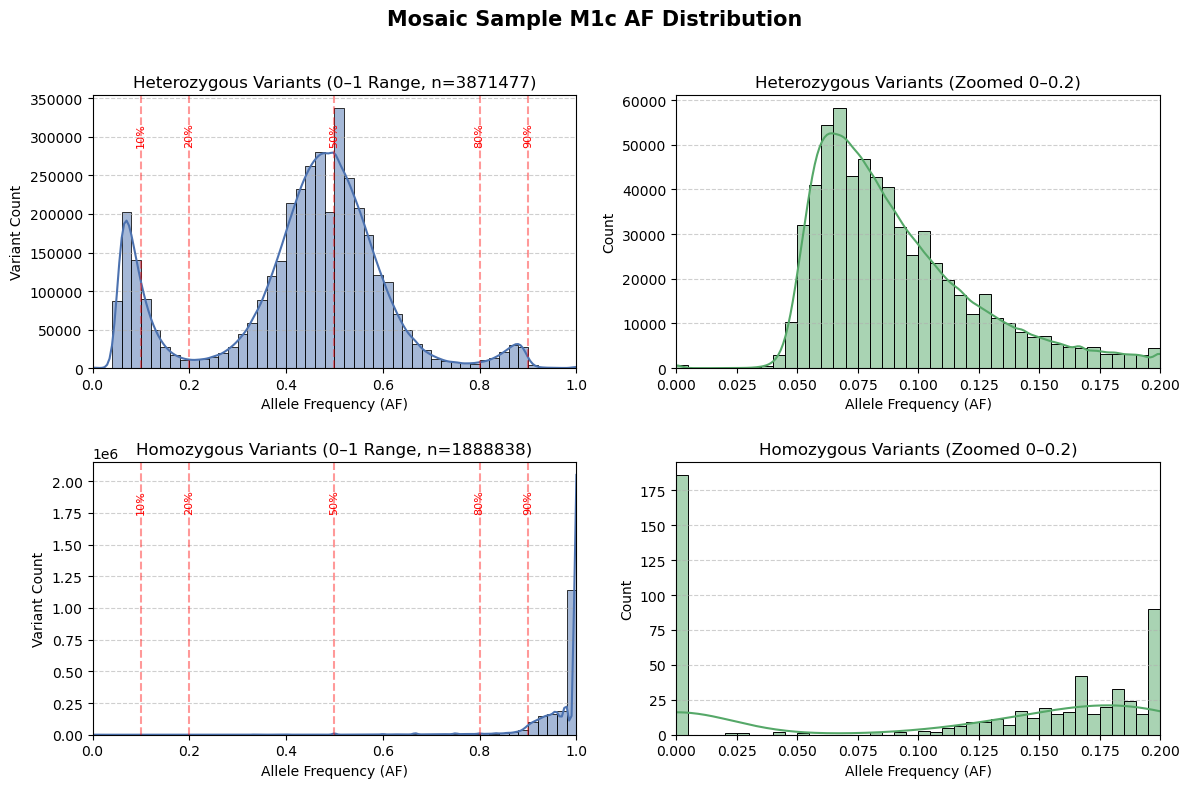

In [50]:
# Suppose your DataFrame is named df and has column 'AF'
plot_af_distribution_by_genotype(M1c_decomposed_short, af_col="AF", title="Mosaic Sample M1c AF Distribution")

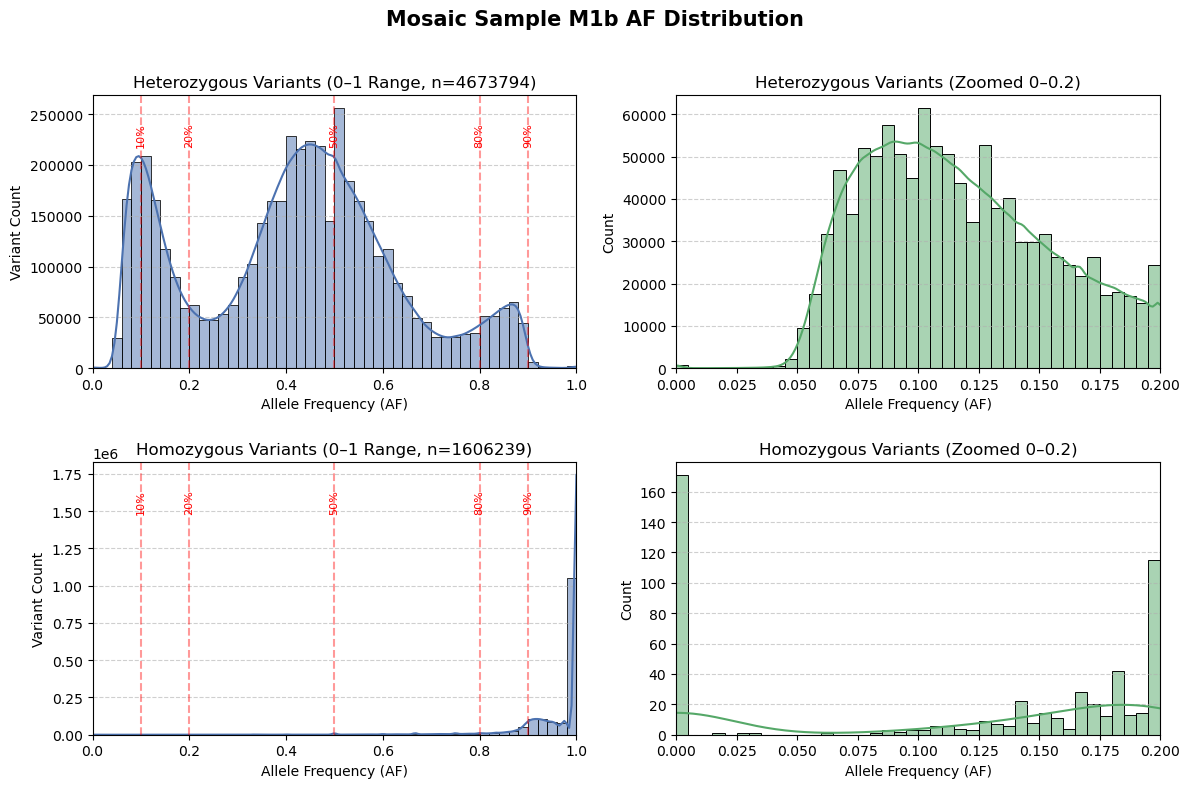

In [51]:
# Suppose your DataFrame is named df and has column 'AF'
plot_af_distribution_by_genotype(M1b_decomposed_short, af_col="AF", title="Mosaic Sample M1b AF Distribution")

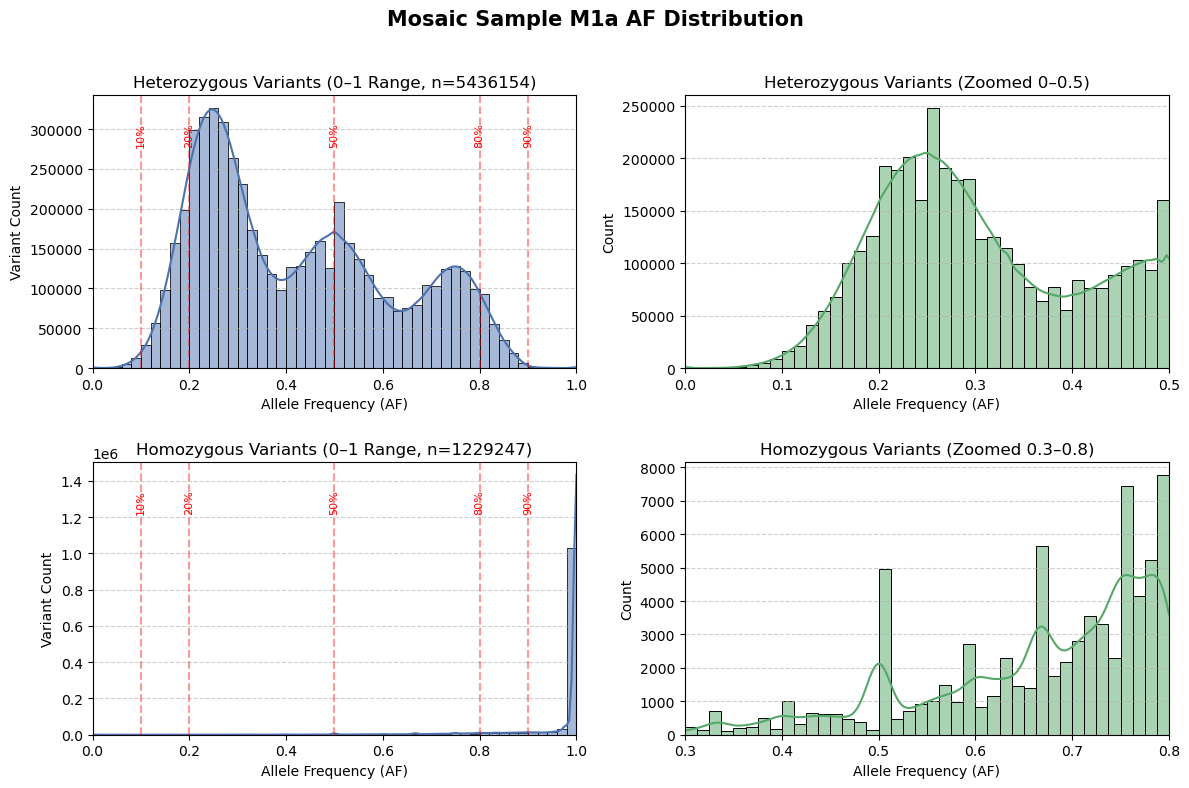

In [63]:
# Suppose your DataFrame is named df and has column 'AF'
plot_af_distribution_by_genotype(M1a_decomposed, af_col="AF", title="Mosaic Sample M1a AF Distribution")

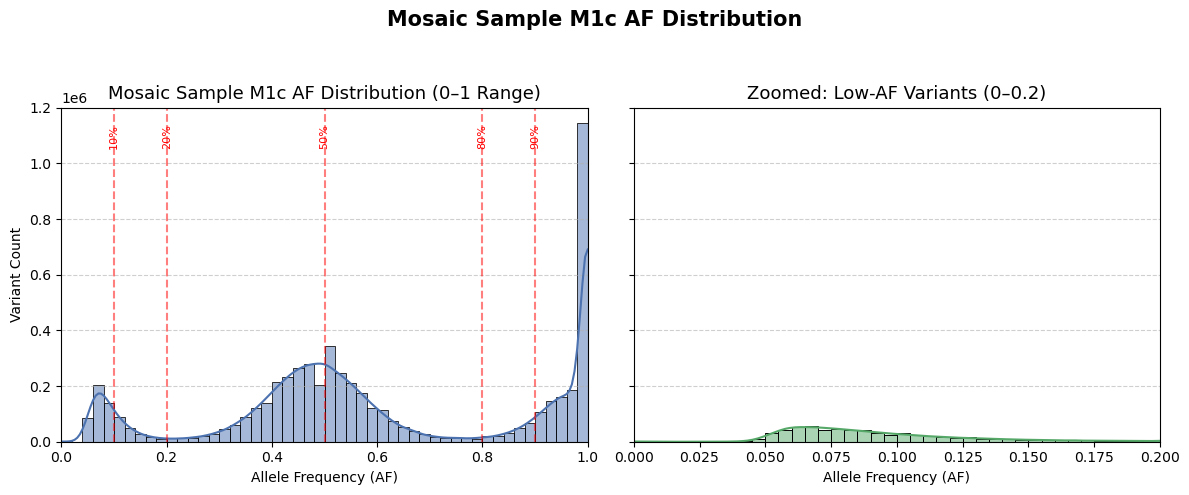

In [32]:
# Suppose your DataFrame is named df and has column 'AF'
plot_af_distribution(M1c_decomposed_short, af_col="AF", title="Mosaic Sample M1c AF Distribution")

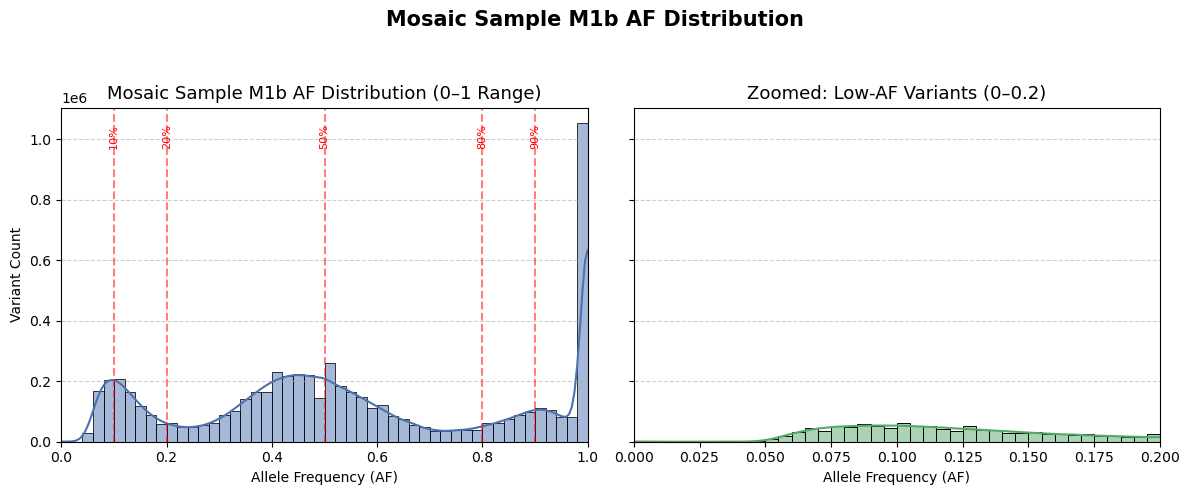

In [29]:
# Suppose your DataFrame is named df and has column 'AF'
plot_af_distribution(M1b_decomposed_short, af_col="AF", title="Mosaic Sample M1b AF Distribution")

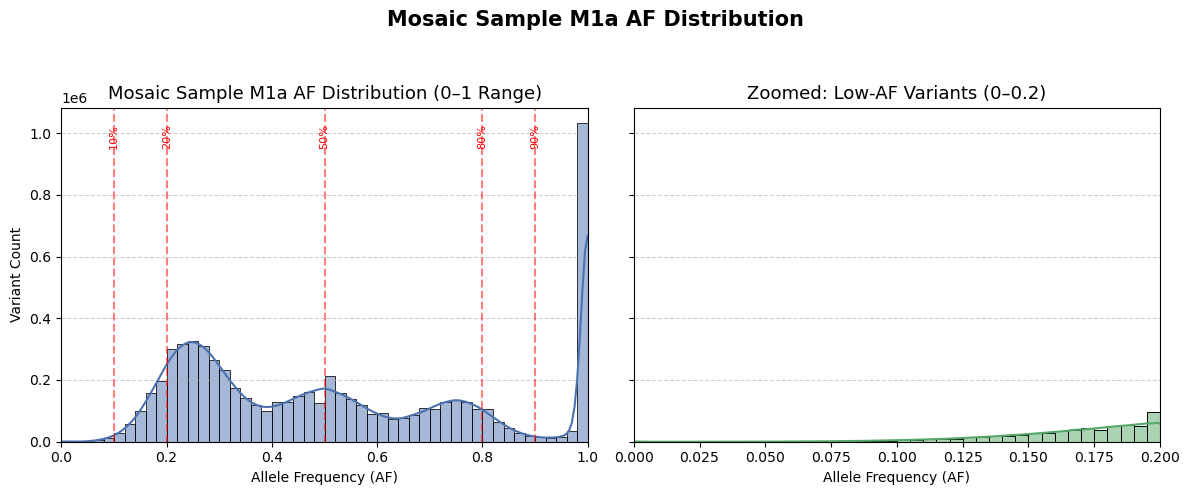

In [30]:
# Suppose your DataFrame is named df and has column 'AF'
plot_af_distribution(M1a_decomposed, af_col="AF", title="Mosaic Sample M1a AF Distribution")

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Filter homozygous ALT variants ---
homo_alt = M1b[
    (M1c["GT"].isin(["1/1", "1|1"])) &
    (M1c["AF"].notna())
].copy()
homo_alt["AF"] = pd.to_numeric(homo_alt["AF"], errors="coerce").dropna()

# --- Filter heterozygous variants ---
het = M1c[
    (M1c["GT"].isin(["0/1", "1/0", "0|1", "1|0"])) &
    (M1c["AF"].notna())
].copy()
het["AF"] = pd.to_numeric(het["AF"], errors="coerce").dropna()

# --- Create subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Homozygous ALT plot ---
sns.histplot(homo_alt["AF"], bins=50, kde=True, color="#4C72B0", edgecolor="black", ax=axes[0])
axes[0].set_title("Homozygous ALT (1/1, 1|1)", fontsize=13)
axes[0].set_xlabel("Allele Frequency (AF)")
axes[0].set_ylabel("Count")
axes[0].set_xlim(0, 1)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# Add expected AF markers (optional)
expected_vafs = [0.1, 0.2, 0.5, 0.8, 0.9]
for af in expected_vafs:
    axes[0].axvline(af, color="red", linestyle="--", alpha=0.4)

# --- Heterozygous plot ---
sns.histplot(het["AF"], bins=50, kde=True, color="#55A868", edgecolor="black", ax=axes[1])
axes[1].set_title("Heterozygous (0/1, 1/0, 0|1, 1|0)", fontsize=13)
axes[1].set_xlabel("Allele Frequency (AF)")
axes[1].set_xlim(0, 1)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

# Add same expected AF markers
for af in expected_vafs:
    axes[1].axvline(af, color="red", linestyle="--", alpha=0.4)

# --- Final layout ---
fig.suptitle("Allele Frequency (AF) Distributions in Mosaic Sample (M1b) - only HG001 private to HG002", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


/tmp/ipykernel_10593/1558402782.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  homo_alt = M1b[


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [66]:
HG001_unique_to_HG002

,CHROM,POS,REF,ALT,GT,Variant_Type,Variant_Length
0,chr1,797392,G,A,0/1,SNP,0
1,chr1,805514,AC,A,0/1,DEL,1
2,chr1,807445,A,G,0/1,SNP,0
3,chr1,807641,T,C,0/1,SNP,0
4,chr1,814264,T,C,1/1,SNP,0
...,...,...,...,...,...,...,...
1434605,chr22,50791067,C,T,0/1,SNP,0
1434606,chr22,50791178,A,T,0/1,SNP,0
1434607,chr22,50791190,G,A,0/1,SNP,0
1434608,chr22,50792591,T,C,0/1,SNP,0


In [28]:
import pandas as pd

def variant_benchmark(truth_df, test_df):
    """
    Compare a truth/reference VCF DataFrame to a test/mosaic VCF DataFrame.

    Parameters
    ----------
    truth_df : pd.DataFrame
        Truth variants (columns: CHROM, POS, REF, ALT)
    test_df : pd.DataFrame
        Observed variants (columns: CHROM, POS, REF, ALT)

    Returns
    -------
    metrics : dict
        Counts and accuracy metrics: TP, FP, FN, Sensitivity, Specificity, F1
    """

    # Create a unique variant key for both DataFrames
    truth_df["VAR_KEY"] = (
        truth_df["CHROM"].astype(str) + "_" +
        truth_df["POS"].astype(str) + "_" +
        truth_df["REF"] + "_" +
        truth_df["ALT"]
    )
    test_df["VAR_KEY"] = (
        test_df["CHROM"].astype(str) + "_" +
        test_df["POS"].astype(str) + "_" +
        test_df["REF"] + "_" +
        test_df["ALT"]
    )

    truth_set = set(truth_df["VAR_KEY"])
    test_set = set(test_df["VAR_KEY"])

    # Core classification
    TP = truth_set & test_set
    FN = truth_set - test_set
    FP = test_set - truth_set

    # Counts
    TP_count = len(TP)
    FN_count = len(FN)
    FP_count = len(FP)

    # Metrics
    sensitivity = TP_count / (TP_count + FN_count) if (TP_count + FN_count) else 0
    specificity = TP_count / (TP_count + FP_count) if (TP_count + FP_count) else 0
    f1_score = (2 * sensitivity * specificity) / (sensitivity + specificity) if (sensitivity + specificity) else 0

    tp_df = truth_df[truth_df["VAR_KEY"].isin(TP)].copy()
    
    # Collect results
    metrics = {
        "True Positives": TP_count,
        "False Negatives": FN_count,
        "False Positives": FP_count,
        "Sensitivity (Recall)": round(sensitivity, 4),
        "Specificity (Precision)": round(specificity, 4),
        "F1 Score": round(f1_score, 4,),
        "TP_variants": tp_df
    }

    return metrics


In [76]:
# Append the two DataFrames by row
combined_df = pd.concat([HG001_unique_to_HG002, HG002_unique_to_HG001], 
                        axis=0,       # stack vertically (rows)
                        ignore_index=True)  # reset index after concatenation

In [77]:
combined_df

,CHROM,POS,REF,ALT,GT,Variant_Type,Variant_Length,VAR_KEY
0,chr1,797392,G,A,0/1,SNP,0,chr1_797392_G_A
1,chr1,805514,AC,A,0/1,DEL,1,chr1_805514_AC_A
2,chr1,807445,A,G,0/1,SNP,0,chr1_807445_A_G
3,chr1,807641,T,C,0/1,SNP,0,chr1_807641_T_C
4,chr1,814264,T,C,1/1,SNP,0,chr1_814264_T_C
...,...,...,...,...,...,...,...,...
3029558,chr22,50787445,TAAG,T,0/1,DEL,3,NaN
3029559,chr22,50789509,A,C,1/1,SNP,0,NaN
3029560,chr22,50790482,G,A,0/1,SNP,0,NaN
3029561,chr22,50791276,G,GC,0/1,INS,1,NaN


In [5]:
valid_chroms = [f"chr{i}" for i in range(1, 23)]

In [6]:
M1a_decomposed_short_chr= M1a_decomposed_short[M1a_decomposed_short["CHROM"].isin(valid_chroms)].copy()
M1b_decomposed_short_chr= M1b_decomposed_short[M1b_decomposed_short["CHROM"].isin(valid_chroms)].copy()
M1c_decomposed_short_chr= M1c_decomposed_short[M1c_decomposed_short["CHROM"].isin(valid_chroms)].copy()
M2a_decomposed_short_chr= M2a_decomposed_short[M2a_decomposed_short["CHROM"].isin(valid_chroms)].copy()
M2b_decomposed_short_chr= M2b_decomposed_short[M2b_decomposed_short["CHROM"].isin(valid_chroms)].copy()
M2c_decomposed_short_chr= M2c_decomposed_short[M2c_decomposed_short["CHROM"].isin(valid_chroms)].copy()

In [29]:
M1a_metrics_HG002_HG001_het=variant_benchmark(HG002_unique_to_HG001_het, M1a_decomposed_short_chr)
M1b_metrics_HG002_HG001_het=variant_benchmark(HG002_unique_to_HG001_het, M1b_decomposed_short_chr)
M1c_metrics_HG002_HG001_het=variant_benchmark(HG002_unique_to_HG001_het, M1c_decomposed_short_chr)
M1a_metrics_HG001_het=variant_benchmark(HG001_unique_to_HG002_het, M1a_decomposed_short_chr)
M1b_metrics_HG001_het=variant_benchmark(HG001_unique_to_HG002_het, M1b_decomposed_short_chr)
M1c_metrics_HG001_het=variant_benchmark(HG001_unique_to_HG002_het, M1c_decomposed_short_chr)
M2a_metrics_HG005_het=variant_benchmark(HG005_unique_to_HG002_het, M2a_decomposed_short_chr)
M2b_metrics_HG005_het=variant_benchmark(HG005_unique_to_HG002_het, M2b_decomposed_short_chr)
M2c_metrics_HG005_het=variant_benchmark(HG005_unique_to_HG002_het, M2c_decomposed_short_chr)
M2a_metrics_HG002_HG005_het=variant_benchmark(HG002_unique_to_HG005_het, M2a_decomposed_short_chr)
M2b_metrics_HG002_HG005_het=variant_benchmark(HG002_unique_to_HG005_het, M2b_decomposed_short_chr)
M2c_metrics_HG002_HG005_het=variant_benchmark(HG002_unique_to_HG005_het, M2c_decomposed_short_chr)

In [59]:
M1a_metrics_HG002_HG001_hom=variant_benchmark(HG002_unique_to_HG001_hom, M1a_decomposed_short_chr)
M1b_metrics_HG002_HG001_hom=variant_benchmark(HG002_unique_to_HG001_hom, M1b_decomposed_short_chr)
M1c_metrics_HG002_HG001_hom=variant_benchmark(HG002_unique_to_HG001_hom, M1c_decomposed_short_chr)
M1a_metrics_HG001_hom=variant_benchmark(HG001_unique_to_HG002_hom, M1a_decomposed_short_chr)
M1b_metrics_HG001_hom=variant_benchmark(HG001_unique_to_HG002_hom, M1b_decomposed_short_chr)
M1c_metrics_HG001_hom=variant_benchmark(HG001_unique_to_HG002_hom, M1c_decomposed_short_chr)
M2a_metrics_HG005_hom=variant_benchmark(HG005_unique_to_HG002_hom, M2a_decomposed_short_chr)
M2b_metrics_HG005_hom=variant_benchmark(HG005_unique_to_HG002_hom, M2b_decomposed_short_chr)
M2c_metrics_HG005_hom=variant_benchmark(HG005_unique_to_HG002_hom, M2c_decomposed_short_chr)
M2a_metrics_HG002_HG005_hom=variant_benchmark(HG002_unique_to_HG005_hom, M2a_decomposed_short_chr)
M2b_metrics_HG002_HG005_hom=variant_benchmark(HG002_unique_to_HG005_hom, M2b_decomposed_short_chr)
M2c_metrics_HG002_HG005_hom=variant_benchmark(HG002_unique_to_HG005_hom, M2c_decomposed_short_chr)

In [74]:
M1a_metrics_HG002_HG001_het=variant_benchmark_by_type(HG002_unique_to_HG001_het, M1a_decomposed_short_chr)
M1b_metrics_HG002_HG001_het=variant_benchmark_by_type(HG002_unique_to_HG001_het, M1b_decomposed_short_chr)
M1c_metrics_HG002_HG001_het=variant_benchmark_by_type(HG002_unique_to_HG001_het, M1c_decomposed_short_chr)
M1a_metrics_HG001_het=variant_benchmark_by_type(HG001_unique_to_HG002_het, M1a_decomposed_short_chr)
M1b_metrics_HG001_het=variant_benchmark_by_type(HG001_unique_to_HG002_het, M1b_decomposed_short_chr)
M1c_metrics_HG001_het=variant_benchmark_by_type(HG001_unique_to_HG002_het, M1c_decomposed_short_chr)
M2a_metrics_HG005_het=variant_benchmark_by_type(HG005_unique_to_HG002_het, M2a_decomposed_short_chr)
M2b_metrics_HG005_het=variant_benchmark_by_type(HG005_unique_to_HG002_het, M2b_decomposed_short_chr)
M2c_metrics_HG005_het=variant_benchmark_by_type(HG005_unique_to_HG002_het, M2c_decomposed_short_chr)
M2a_metrics_HG002_HG005_het=variant_benchmark_by_type(HG002_unique_to_HG005_het, M2a_decomposed_short_chr)
M2b_metrics_HG002_HG005_het=variant_benchmark_by_type(HG002_unique_to_HG005_het, M2b_decomposed_short_chr)
M2c_metrics_HG002_HG005_het=variant_benchmark_by_type(HG002_unique_to_HG005_het, M2c_decomposed_short_chr)

In [75]:
M1a_metrics_HG002_HG001_hom=variant_benchmark_by_type(HG002_unique_to_HG001_hom, M1a_decomposed_short_chr)
M1b_metrics_HG002_HG001_hom=variant_benchmark_by_type(HG002_unique_to_HG001_hom, M1b_decomposed_short_chr)
M1c_metrics_HG002_HG001_hom=variant_benchmark_by_type(HG002_unique_to_HG001_hom, M1c_decomposed_short_chr)
M1a_metrics_HG001_hom=variant_benchmark_by_type(HG001_unique_to_HG002_hom, M1a_decomposed_short_chr)
M1b_metrics_HG001_hom=variant_benchmark_by_type(HG001_unique_to_HG002_hom, M1b_decomposed_short_chr)
M1c_metrics_HG001_hom=variant_benchmark_by_type(HG001_unique_to_HG002_hom, M1c_decomposed_short_chr)
M2a_metrics_HG005_hom=variant_benchmark_by_type(HG005_unique_to_HG002_hom, M2a_decomposed_short_chr)
M2b_metrics_HG005_hom=variant_benchmark_by_type(HG005_unique_to_HG002_hom, M2b_decomposed_short_chr)
M2c_metrics_HG005_hom=variant_benchmark_by_type(HG005_unique_to_HG002_hom, M2c_decomposed_short_chr)
M2a_metrics_HG002_HG005_hom=variant_benchmark_by_type(HG002_unique_to_HG005_hom, M2a_decomposed_short_chr)
M2b_metrics_HG002_HG005_hom=variant_benchmark_by_type(HG002_unique_to_HG005_hom, M2b_decomposed_short_chr)
M2c_metrics_HG002_HG005_hom=variant_benchmark_by_type(HG002_unique_to_HG005_hom, M2c_decomposed_short_chr)

In [81]:
# Collect all results into a dictionary
results = {
    "M1a_HG002_HG001_hom": M1a_metrics_HG002_HG001_hom,
    "M1b_HG002_HG001_hom": M1b_metrics_HG002_HG001_hom,
    "M1c_HG002_HG001_hom": M1c_metrics_HG002_HG001_hom,
    "M1a_HG001_hom": M1a_metrics_HG001_hom,
    "M1b_HG001_hom": M1b_metrics_HG001_hom,
    "M1c_HG001_hom": M1c_metrics_HG001_hom,
    "M2a_HG005_hom": M2a_metrics_HG005_hom,
    "M2b_HG005_hom": M2b_metrics_HG005_hom,
    "M2c_HG005_hom": M2c_metrics_HG005_hom,
    "M2a_HG002_HG005_hom": M2a_metrics_HG002_HG005_hom,
    "M2b_HG002_HG005_hom": M2b_metrics_HG002_HG005_hom,
    "M2c_HG002_HG005_hom": M2c_metrics_HG002_HG005_hom,
}
# --- Example usage with your results dictionary ---
metrics_summary_extended = summarize_variant_type_metrics(results)

# --- Display summary ---
print("\n=== Mosaic Benchmark Summary by Variant Type ===\n")
print(metrics_summary_extended.to_string(index=False))



=== Mosaic Benchmark Summary by Variant Type ===

  Reference Mosaic Type Variant_Type  True Positives  False Negatives  False Positives  Sensitivity (Recall)  Specificity (Precision)  F1 Score
      HG001    M1a  hom          DEL           22888              300           611864                0.9871                   0.0361    0.0696
      HG001    M1a  hom          INS           22772              598           600292                0.9744                   0.0365    0.0705
      HG001    M1a  hom      Overall          257668             1916          6176036                0.9926                   0.0400    0.0770
      HG001    M1a  hom          SNP          212008             1018          4963880                0.9952                   0.0410    0.0787
      HG001    M1b  hom          DEL           22944              244           563120                0.9895                   0.0391    0.0753
      HG001    M1b  hom          INS           22917              453           56221

In [82]:
# Collect all results into a dictionary
results = {
    "M1a_HG002_HG001_het": M1a_metrics_HG002_HG001_het,
    "M1b_HG002_HG001_het": M1b_metrics_HG002_HG001_het,
    "M1c_HG002_HG001_het": M1c_metrics_HG002_HG001_het,
    "M1a_HG001_het": M1a_metrics_HG001_het,
    "M1b_HG001_het": M1b_metrics_HG001_het,
    "M1c_HG001_het": M1c_metrics_HG001_het,
    "M2a_HG005_het": M2a_metrics_HG005_het,
    "M2b_HG005_het": M2b_metrics_HG005_het,
    "M2c_HG005_het": M2c_metrics_HG005_het,
    "M2a_HG002_HG005_het": M2a_metrics_HG002_HG005_het,
    "M2b_HG002_HG005_het": M2b_metrics_HG002_HG005_het,
    "M2c_HG002_HG005_het": M2c_metrics_HG002_HG005_het,
}
# --- Example usage with your results dictionary ---
metrics_summary_extended = summarize_variant_type_metrics(results)

# --- Display summary ---
print("\n=== Mosaic Benchmark Summary by Variant Type ===\n")
print(metrics_summary_extended.to_string(index=False))



=== Mosaic Benchmark Summary by Variant Type ===

  Reference Mosaic Type Variant_Type  True Positives  False Negatives  False Positives  Sensitivity (Recall)  Specificity (Precision)  F1 Score
      HG001    M1a  het          DEL           94162            12509           540590                0.8827                   0.1483    0.2540
      HG001    M1a  het          INS           79692            18977           543372                0.8077                   0.1279    0.2208
      HG001    M1a  het      Overall         1135824            39196          5297880                0.9666                   0.1765    0.2986
      HG001    M1a  het          SNP          961970             7710          4213918                0.9920                   0.1859    0.3131
      HG001    M1b  het          DEL          104414             2257           481650                0.9788                   0.1782    0.3015
      HG001    M1b  het          INS           94605             4064           49053

In [72]:
# Collect all results into a dictionary
results = {
    "M1a_HG002_HG001_hom": M1a_metrics_HG002_HG001_hom,
    "M1b_HG002_HG001_hom": M1b_metrics_HG002_HG001_hom,
    "M1c_HG002_HG001_hom": M1c_metrics_HG002_HG001_hom,
    "M1a_HG001_hom": M1a_metrics_HG001_hom,
    "M1b_HG001_hom": M1b_metrics_HG001_hom,
    "M1c_HG001_hom": M1c_metrics_HG001_hom,
    "M2a_HG005_hom": M2a_metrics_HG005_hom,
    "M2b_HG005_hom": M2b_metrics_HG005_hom,
    "M2c_HG005_hom": M2c_metrics_HG005_hom,
    "M2a_HG002_HG005_hom": M2a_metrics_HG002_HG005_hom,
    "M2b_HG002_HG005_hom": M2b_metrics_HG002_HG005_hom,
    "M2c_HG002_HG005_hom": M2c_metrics_HG002_HG005_hom,
}
# --- Combine all results into a DataFrame ---
metrics_df = pd.DataFrame(results).T.reset_index()
metrics_df.rename(columns={"index": "Sample_Comparison"}, inplace=True)

# Keep key columns
metrics_summary = metrics_df[
    ["Sample_Comparison", "True Positives", "False Negatives",
     "Sensitivity (Recall)", "Specificity (Precision)", "F1 Score"]
].copy()

# --- Extract identifiers from Sample_Comparison ---
metrics_summary["Mosaic"] = metrics_summary["Sample_Comparison"].str.extract(r"(M\d[a-c])")

# Capture Reference (handles _hom/_het suffix correctly)
metrics_summary["Reference"] = metrics_summary["Sample_Comparison"].str.extract(
    r"_(HG\d{3}(?:_HG\d{3})?)(?=_(?:hom|het)|$)"
)

# Capture Type (_hom or _het)
metrics_summary["Type"] = metrics_summary["Sample_Comparison"].str.extract(r"_(hom|het)$")

# --- Clean up formatting ---
metrics_summary["Sensitivity (Recall)"] = metrics_summary["Sensitivity (Recall)"].round(4)
metrics_summary["Specificity (Precision)"] = metrics_summary["Specificity (Precision)"].round(4)
metrics_summary["F1 Score"] = metrics_summary["F1 Score"].round(4)

# --- Sort and reorder for clarity ---
metrics_summary = metrics_summary.sort_values(["Reference", "Mosaic", "Type"], ignore_index=True)

metrics_summary = metrics_summary[
    ["Reference", "Mosaic", "Type", "True Positives", "False Negatives",
     "Sensitivity (Recall)", "Specificity (Precision)", "F1 Score"]
]

# --- Display results ---
print("\n=== Mosaic Benchmark Summary (Extended) ===\n")
print(metrics_summary.to_string(index=False))


=== Mosaic Benchmark Summary (Extended) ===

  Reference Mosaic Type  True Positives  False Negatives  Sensitivity (Recall)  Specificity (Precision)  F1 Score
      HG001    M1a  hom        257668.0           1916.0                0.9926                   0.0400    0.0770
      HG001    M1b  hom        257998.0           1586.0                0.9939                   0.0426    0.0817
      HG001    M1c  hom        258055.0           1529.0                0.9941                   0.0465    0.0889
HG002_HG001    M1a  hom        291784.0           2576.0                0.9912                   0.0454    0.0867
HG002_HG001    M1b  hom        277105.0          17255.0                0.9414                   0.0457    0.0872
HG002_HG001    M1c  hom        231395.0          62965.0                0.7861                   0.0417    0.0792
HG002_HG005    M2a  hom        355700.0           2665.0                0.9926                   0.0541    0.1026
HG002_HG005    M2b  hom        337850.0   

In [73]:
# Collect all results into a dictionary
results = {
    "M1a_HG002_HG001_het": M1a_metrics_HG002_HG001_het,
    "M1b_HG002_HG001_het": M1b_metrics_HG002_HG001_het,
    "M1c_HG002_HG001_het": M1c_metrics_HG002_HG001_het,
    "M1a_HG001_het": M1a_metrics_HG001_het,
    "M1b_HG001_het": M1b_metrics_HG001_het,
    "M1c_HG001_het": M1c_metrics_HG001_het,
    "M2a_HG005_het": M2a_metrics_HG005_het,
    "M2b_HG005_het": M2b_metrics_HG005_het,
    "M2c_HG005_het": M2c_metrics_HG005_het,
    "M2a_HG002_HG005_het": M2a_metrics_HG002_HG005_het,
    "M2b_HG002_HG005_het": M2b_metrics_HG002_HG005_het,
    "M2c_HG002_HG005_het": M2c_metrics_HG002_HG005_het,
}
# --- Combine all results into a DataFrame ---
metrics_df = pd.DataFrame(results).T.reset_index()
metrics_df.rename(columns={"index": "Sample_Comparison"}, inplace=True)

# Keep key columns
metrics_summary = metrics_df[
    ["Sample_Comparison", "True Positives", "False Negatives",
     "Sensitivity (Recall)", "Specificity (Precision)", "F1 Score"]
].copy()

# --- Extract identifiers from Sample_Comparison ---
metrics_summary["Mosaic"] = metrics_summary["Sample_Comparison"].str.extract(r"(M\d[a-c])")

# Capture Reference (handles _hom/_het suffix correctly)
metrics_summary["Reference"] = metrics_summary["Sample_Comparison"].str.extract(
    r"_(HG\d{3}(?:_HG\d{3})?)(?=_(?:hom|het)|$)"
)

# Capture Type (_hom or _het)
metrics_summary["Type"] = metrics_summary["Sample_Comparison"].str.extract(r"_(hom|het)$")

# --- Clean up formatting ---
metrics_summary["Sensitivity (Recall)"] = metrics_summary["Sensitivity (Recall)"].round(4)
metrics_summary["Specificity (Precision)"] = metrics_summary["Specificity (Precision)"].round(4)
metrics_summary["F1 Score"] = metrics_summary["F1 Score"].round(4)

# --- Sort and reorder for clarity ---
metrics_summary = metrics_summary.sort_values(["Reference", "Mosaic", "Type"], ignore_index=True)

metrics_summary = metrics_summary[
    ["Reference", "Mosaic", "Type", "True Positives", "False Negatives",
     "Sensitivity (Recall)", "Specificity (Precision)", "F1 Score"]
]

# --- Display results ---
print("\n=== Mosaic Benchmark Summary (Extended) ===\n")
print(metrics_summary.to_string(index=False))


=== Mosaic Benchmark Summary (Extended) ===

  Reference Mosaic Type  True Positives  False Negatives  Sensitivity (Recall)  Specificity (Precision)  F1 Score
      HG001    M1a  het       1135824.0          39196.0                0.9666                   0.1765    0.2986
      HG001    M1b  het       1165971.0           9049.0                0.9923                   0.1925    0.3224
      HG001    M1c  het       1169017.0           6003.0                0.9949                   0.2107    0.3477
HG002_HG001    M1a  het       1239943.0          60647.0                0.9534                   0.1927    0.3206
HG002_HG001    M1b  het        899340.0         401250.0                0.6915                   0.1485    0.2444
HG002_HG001    M1c  het        466495.0         834095.0                0.3587                   0.0841    0.1362
HG002_HG005    M2a  het       1321948.0          64888.0                0.9532                   0.2011    0.3321
HG002_HG005    M2b  het        942508.0   

In [15]:
NA12878_unique_to_NA24385=NA12878_unique_to_NA24385[NA12878_unique_to_NA24385["CHROM"].isin(valid_chroms)].copy()
NA24385_unique_to_NA12878=NA24385_unique_to_NA12878[NA24385_unique_to_NA12878["CHROM"].isin(valid_chroms)].copy()
NA24631_unique_to_NA24385=NA24631_unique_to_NA24385[NA24631_unique_to_NA24385["CHROM"].isin(valid_chroms)].copy()
NA24385_unique_to_NA24631=NA24385_unique_to_NA24631[NA24385_unique_to_NA24631["CHROM"].isin(valid_chroms)].copy()

In [21]:
M1a_metrics_HG002_HG001=variant_benchmark(HG002_unique_to_HG001, M1a_decomposed_short_chr)
M1b_metrics_HG002_HG001=variant_benchmark(HG002_unique_to_HG001, M1b_decomposed_short_chr)
M1c_metrics_HG002_HG001=variant_benchmark(HG002_unique_to_HG001, M1c_decomposed_short_chr)
M1a_metrics_HG001=variant_benchmark(HG001_unique_to_HG002, M1a_decomposed_short_chr)
M1b_metrics_HG001=variant_benchmark(HG001_unique_to_HG002, M1b_decomposed_short_chr)
M1c_metrics_HG001=variant_benchmark(HG001_unique_to_HG002, M1c_decomposed_short_chr)
M2a_metrics_HG005=variant_benchmark(HG005_unique_to_HG002, M2a_decomposed_short_chr)
M2b_metrics_HG005=variant_benchmark(HG005_unique_to_HG002, M2b_decomposed_short_chr)
M2c_metrics_HG005=variant_benchmark(HG005_unique_to_HG002, M2c_decomposed_short_chr)
M2a_metrics_HG002_HG005=variant_benchmark(HG002_unique_to_HG005, M2a_decomposed_short_chr)
M2b_metrics_HG002_HG005=variant_benchmark(HG002_unique_to_HG005, M2b_decomposed_short_chr)
M2c_metrics_HG002_HG005=variant_benchmark(HG002_unique_to_HG005, M2c_decomposed_short_chr)

In [18]:
M1a_metrics_NA24385_NA12878=variant_benchmark(NA24385_unique_to_NA12878, M1a_decomposed_short_chr)
M1b_metrics_NA24385_NA12878=variant_benchmark(NA24385_unique_to_NA12878, M1b_decomposed_short_chr)
M1c_metrics_NA24385_NA12878=variant_benchmark(NA24385_unique_to_NA12878, M1c_decomposed_short_chr)
M1a_metrics_NA12878=variant_benchmark(NA12878_unique_to_NA24385, M1a_decomposed_short_chr)
M1b_metrics_NA12878=variant_benchmark(NA12878_unique_to_NA24385, M1b_decomposed_short_chr)
M1c_metrics_NA12878=variant_benchmark(NA12878_unique_to_NA24385, M1c_decomposed_short_chr)
M2a_metrics_NA24631=variant_benchmark(NA24631_unique_to_NA24385, M2a_decomposed_short_chr)
M2b_metrics_NA24631=variant_benchmark(NA24631_unique_to_NA24385, M2b_decomposed_short_chr)
M2c_metrics_NA24631=variant_benchmark(NA24631_unique_to_NA24385, M2c_decomposed_short_chr)
M2a_metrics_NA24385_NA24631=variant_benchmark(NA24385_unique_to_NA24631, M2a_decomposed_short_chr)
M2b_metrics_NA24385_NA24631=variant_benchmark(NA24385_unique_to_NA24631, M2b_decomposed_short_chr)
M2c_metrics_NA24385_NA24631=variant_benchmark(NA24385_unique_to_NA24631, M2c_decomposed_short_chr)

In [25]:
import pandas as pd

def variant_benchmark_by_type(truth_df, test_df):
    """
    Compare a truth/reference VCF DataFrame to a test/mosaic VCF DataFrame,
    and compute benchmarking metrics per variant type (SNP, INS, DEL).

    Automatically infers:
      - Variant_Type (SNP / INS / DEL / COMPLEX)
      - Variant_Length (|len(ALT) - len(REF)|)

    Parameters
    ----------
    truth_df : pd.DataFrame
        Truth variants (columns: CHROM, POS, REF, ALT)
    test_df : pd.DataFrame
        Observed variants (columns: CHROM, POS, REF, ALT)

    Returns
    -------
    metrics_all : dict
        Overall metrics + per-type metrics (SNP, INS, DEL)
    """

    def infer_variant_info(df):
        """Infer Variant_Type and Variant_Length from REF/ALT."""
        df = df.copy()
        def get_type_and_len(ref, alt):
            if len(ref) == 1 and len(alt) == 1:
                vartype = "SNP"
            elif len(alt) > len(ref):
                vartype = "INS"
            elif len(alt) < len(ref):
                vartype = "DEL"
            else:
                vartype = "COMPLEX"
            return vartype, abs(len(alt) - len(ref))
        df[["Variant_Type", "Variant_Length"]] = [
            get_type_and_len(r, a) for r, a in zip(df["REF"], df["ALT"])
        ]
        df["Variant_Type"] = df["Variant_Type"].astype(str)
        df["Variant_Length"] = df["Variant_Length"].astype(int)
        return df

    # Infer info if not already present
    truth_df = infer_variant_info(truth_df)
    test_df = infer_variant_info(test_df)

    # Create unique variant key
    truth_df["VAR_KEY"] = (
        truth_df["CHROM"].astype(str) + "_" +
        truth_df["POS"].astype(str) + "_" +
        truth_df["REF"] + "_" +
        truth_df["ALT"]
    )
    test_df["VAR_KEY"] = (
        test_df["CHROM"].astype(str) + "_" +
        test_df["POS"].astype(str) + "_" +
        test_df["REF"] + "_" +
        test_df["ALT"]
    )

    def compute_metrics(tp, fn, fp):
        sens = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) else 0
        spec = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) else 0
        f1 = (2 * sens * spec) / (sens + spec) if (sens + spec) else 0
        return {
            "TP": len(tp),
            "FN": len(fn),
            "FP": len(fp),
            "Sensitivity": round(sens, 4),
            "Specificity": round(spec, 4),
            "F1": round(f1, 4)
        }

    metrics_all = {}

    # --- Overall ---
    truth_set = set(truth_df["VAR_KEY"])
    test_set = set(test_df["VAR_KEY"])
    TP = truth_set & test_set
    FN = truth_set - test_set
    FP = test_set - truth_set
    metrics_all["Overall"] = compute_metrics(TP, FN, FP)

    # --- Per Variant Type ---
    for vartype in ["SNP", "INS", "DEL"]:
        truth_sub = truth_df[truth_df["Variant_Type"] == vartype]
        test_sub = test_df[test_df["Variant_Type"] == vartype]

        truth_set = set(truth_sub["VAR_KEY"])
        test_set = set(test_sub["VAR_KEY"])

        tp = truth_set & test_set
        fn = truth_set - test_set
        fp = test_set - truth_set

        metrics_all[vartype] = compute_metrics(tp, fn, fp)

    return metrics_all


In [27]:
M1a_metrics_HG002_HG001=variant_benchmark_by_type(HG002_unique_to_HG001, M1a_decomposed_short_chr)
M1b_metrics_HG002_HG001=variant_benchmark_by_type(HG002_unique_to_HG001, M1b_decomposed_short_chr)
M1c_metrics_HG002_HG001=variant_benchmark_by_type(HG002_unique_to_HG001, M1c_decomposed_short_chr)
M1a_metrics_HG001=variant_benchmark_by_type(HG001_unique_to_HG002, M1a_decomposed_short_chr)
M1b_metrics_HG001=variant_benchmark_by_type(HG001_unique_to_HG002, M1b_decomposed_short_chr)
M1c_metrics_HG001=variant_benchmark_by_type(HG001_unique_to_HG002, M1c_decomposed_short_chr)
M2a_metrics_HG005=variant_benchmark_by_type(HG005_unique_to_HG002, M2a_decomposed_short_chr)
M2b_metrics_HG005=variant_benchmark_by_type(HG005_unique_to_HG002, M2b_decomposed_short_chr)
M2c_metrics_HG005=variant_benchmark_by_type(HG005_unique_to_HG002, M2c_decomposed_short_chr)
M2a_metrics_HG002_HG005=variant_benchmark_by_type(HG002_unique_to_HG005, M2a_decomposed_short_chr)
M2b_metrics_HG002_HG005=variant_benchmark_by_type(HG002_unique_to_HG005, M2b_decomposed_short_chr)
M2c_metrics_HG002_HG005=variant_benchmark_by_type(HG002_unique_to_HG005, M2c_decomposed_short_chr)

In [28]:
M1a_metrics_NA24385_NA12878=variant_benchmark_by_type(NA24385_unique_to_NA12878, M1a_decomposed_short_chr)
M1b_metrics_NA24385_NA12878=variant_benchmark_by_type(NA24385_unique_to_NA12878, M1b_decomposed_short_chr)
M1c_metrics_NA24385_NA12878=variant_benchmark_by_type(NA24385_unique_to_NA12878, M1c_decomposed_short_chr)
M1a_metrics_NA12878=variant_benchmark_by_type(NA12878_unique_to_NA24385, M1a_decomposed_short_chr)
M1b_metrics_NA12878=variant_benchmark_by_type(NA12878_unique_to_NA24385, M1b_decomposed_short_chr)
M1c_metrics_NA12878=variant_benchmark_by_type(NA12878_unique_to_NA24385, M1c_decomposed_short_chr)
M2a_metrics_NA24631=variant_benchmark_by_type(NA24631_unique_to_NA24385, M2a_decomposed_short_chr)
M2b_metrics_NA24631=variant_benchmark_by_type(NA24631_unique_to_NA24385, M2b_decomposed_short_chr)
M2c_metrics_NA24631=variant_benchmark_by_type(NA24631_unique_to_NA24385, M2c_decomposed_short_chr)
M2a_metrics_NA24385_NA24631=variant_benchmark_by_type(NA24385_unique_to_NA24631, M2a_decomposed_short_chr)
M2b_metrics_NA24385_NA24631=variant_benchmark_by_type(NA24385_unique_to_NA24631, M2b_decomposed_short_chr)
M2c_metrics_NA24385_NA24631=variant_benchmark_by_type(NA24385_unique_to_NA24631, M2c_decomposed_short_chr)

In [80]:
import pandas as pd

def summarize_variant_type_metrics(results_dict):
    """
    Flatten nested variant-type benchmarking results into a summary DataFrame.

    Parameters
    ----------
    results_dict : dict
        Each key is a sample name (e.g. "M1a_HG002_HG001_hom")
        Each value is a dict returned from variant_benchmark_by_type()

    Returns
    -------
    pd.DataFrame
        Flattened metrics table for Overall, SNP, INS, and DEL,
        including 'hom' or 'het' type identifiers.
    """
    records = []

    for sample, metrics in results_dict.items():
        for vartype, stats in metrics.items():
            record = {
                "Sample_Comparison": sample,
                "Variant_Type": vartype,
                "True Positives": stats["TP"],
                "False Negatives": stats["FN"],
                "False Positives": stats["FP"],
                "Sensitivity (Recall)": stats["Sensitivity"],
                "Specificity (Precision)": stats["Specificity"],
                "F1 Score": stats["F1"]
            }
            records.append(record)

    df = pd.DataFrame(records)

    # --- Extract mosaic, reference, and type identifiers ---
    df["Mosaic"] = df["Sample_Comparison"].str.extract(r"(M\d[a-c])")

    # Reference (handles patterns like _HG002_HG001_hom or _HG005_het)
    df["Reference"] = df["Sample_Comparison"].str.extract(
        r"_(HG\d{3}(?:_HG\d{3})?)(?=_(?:hom|het)|$)"
    )

    # Extract Type (_hom or _het)
    df["Type"] = df["Sample_Comparison"].str.extract(r"_(hom|het)$")

    # --- Clean formatting ---
    df = df.sort_values(["Reference", "Mosaic", "Type", "Variant_Type"], ignore_index=True)

    # Reorder columns for clarity
    df = df[
        ["Reference", "Mosaic", "Type", "Variant_Type",
         "True Positives", "False Negatives", "False Positives",
         "Sensitivity (Recall)", "Specificity (Precision)", "F1 Score"]
    ]

    return df


In [34]:
import pandas as pd

def summarize_variant_type_metrics(results_dict):
    """
    Flatten nested variant-type benchmarking results into a summary DataFrame.

    Parameters
    ----------
    results_dict : dict
        Each key is a sample name (e.g. "M1a_HG002_HG001")
        Each value is a dict returned from variant_benchmark_by_type()

    Returns
    -------
    pd.DataFrame
        Flattened metrics table for Overall, SNP, INS, and DEL
    """
    records = []

    for sample, metrics in results_dict.items():
        for vartype, stats in metrics.items():
            record = {
                "Sample_Comparison": sample,
                "Variant_Type": vartype,
                "True Positives": stats["TP"],
                "False Negatives": stats["FN"],
                "False Positives": stats["FP"],
                "Sensitivity (Recall)": stats["Sensitivity"],
                "Specificity (Precision)": stats["Specificity"],
                "F1 Score": stats["F1"]
            }
            records.append(record)

    df = pd.DataFrame(records)

    # Extract mosaic and reference identifiers
    df["Mosaic"] = df["Sample_Comparison"].str.extract(r"(M\d[a-c])")
    metrics_summary["Reference"] = metrics_summary["Sample_Comparison"].str.extract(r"_(HG\d{3}(?:_HG\d{3})?)(?=_(?:hom|het)|$)")


    # Clean formatting
    df = df.sort_values(["Reference", "Mosaic", "Variant_Type"], ignore_index=True)

    # Reorder columns for readability
    df = df[
        ["Reference", "Mosaic", "Variant_Type",
         "True Positives", "False Negatives", "False Positives",
         "Sensitivity (Recall)", "Specificity (Precision)", "F1 Score"]
    ]

    return df


# Collect all results into a dictionary
results = {
    "M1a_HG002_HG001": M1a_metrics_HG002_HG001,
    "M1b_HG002_HG001": M1b_metrics_HG002_HG001,
    "M1c_HG002_HG001": M1c_metrics_HG002_HG001,
    "M1a_HG001": M1a_metrics_HG001,
    "M1b_HG001": M1b_metrics_HG001,
    "M1c_HG001": M1c_metrics_HG001,
    "M2a_HG005": M2a_metrics_HG005,
    "M2b_HG005": M2b_metrics_HG005,
    "M2c_HG005": M2c_metrics_HG005,
    "M2a_HG002_HG005": M2a_metrics_HG002_HG005,
    "M2b_HG002_HG005": M2b_metrics_HG002_HG005,
    "M2c_HG002_HG005": M2c_metrics_HG002_HG005,
}
# --- Example usage with your results dictionary ---
metrics_summary_extended = summarize_variant_type_metrics(results)

# --- Display summary ---
print("\n=== Mosaic Benchmark Summary by Variant Type ===\n")
print(metrics_summary_extended.to_string(index=False))



=== Mosaic Benchmark Summary by Variant Type ===

  Reference Mosaic Variant_Type  True Positives  False Negatives  False Positives  Sensitivity (Recall)  Specificity (Precision)  F1 Score
      HG001    M1a          DEL          117050            12809           517702                0.9014                   0.1844    0.3062
      HG001    M1a          INS          102464            19575           520600                0.8396                   0.1645    0.2750
      HG001    M1a      Overall         1393492            41112          5040212                0.9713                   0.2166    0.3542
      HG001    M1a          SNP         1173978             8728          4001910                0.9926                   0.2268    0.3693
      HG001    M1b          DEL          127358             2501           458706                0.9807                   0.2173    0.3558
      HG001    M1b          INS          117522             4517           467614                0.9630            

In [35]:
# === Collect all your new results ===
results_inhouse = {
    "M1a_NA24385_NA12878": M1a_metrics_NA24385_NA12878,
    "M1b_NA24385_NA12878": M1b_metrics_NA24385_NA12878,
    "M1c_NA24385_NA12878": M1c_metrics_NA24385_NA12878,
    "M1a_NA12878": M1a_metrics_NA12878,
    "M1b_NA12878": M1b_metrics_NA12878,
    "M1c_NA12878": M1c_metrics_NA12878,
    "M2a_NA24631": M2a_metrics_NA24631,
    "M2b_NA24631": M2b_metrics_NA24631,
    "M2c_NA24631": M2c_metrics_NA24631,
    "M2a_NA24385_NA24631": M2a_metrics_NA24385_NA24631,
    "M2b_NA24385_NA24631": M2b_metrics_NA24385_NA24631,
    "M2c_NA24385_NA24631": M2c_metrics_NA24385_NA24631,
}

metrics_summary_extended = summarize_variant_type_metrics(results_inhouse)
# --- Display summary ---
print("\n=== Mosaic Benchmark Summary by Variant Type ===\n")
print(metrics_summary_extended.to_string(index=False))



=== Mosaic Benchmark Summary by Variant Type ===

      Reference Mosaic Variant_Type  True Positives  False Negatives  False Positives  Sensitivity (Recall)  Specificity (Precision)  F1 Score
        NA12878    M1a          DEL          172162            46038           462590                0.7890                   0.2712    0.4037
        NA12878    M1a          INS          167309            62572           455755                0.7278                   0.2685    0.3923
        NA12878    M1a      Overall         1619919           202915          4813785                0.8887                   0.2518    0.3924
        NA12878    M1a          SNP         1280448            94305          3895440                0.9314                   0.2474    0.3909
        NA12878    M1b          DEL          200995            17205           385069                0.9212                   0.3430    0.4998
        NA12878    M1b          INS          205326            24555           379810      

In [25]:
import pandas as pd

# Collect all results into a dictionary
results = {
    "M1a_HG002_HG001": M1a_metrics_HG002_HG001,
    "M1b_HG002_HG001": M1b_metrics_HG002_HG001,
    "M1c_HG002_HG001": M1c_metrics_HG002_HG001,
    "M1a_HG001": M1a_metrics_HG001,
    "M1b_HG001": M1b_metrics_HG001,
    "M1c_HG001": M1c_metrics_HG001,
    "M2a_HG005": M2a_metrics_HG005,
    "M2b_HG005": M2b_metrics_HG005,
    "M2c_HG005": M2c_metrics_HG005,
    "M2a_HG002_HG005": M2a_metrics_HG002_HG005,
    "M2b_HG002_HG005": M2b_metrics_HG002_HG005,
    "M2c_HG002_HG005": M2c_metrics_HG002_HG005,
}

import pandas as pd

# --- Combine all results into a DataFrame ---
metrics_df = pd.DataFrame(results).T.reset_index()
metrics_df.rename(columns={"index": "Sample_Comparison"}, inplace=True)

# Keep key columns
metrics_summary = metrics_df[
    ["Sample_Comparison", "True Positives", "False Negatives",
     "Sensitivity (Recall)", "Specificity (Precision)", "F1 Score"]
]

# Extract mosaic and reference parts
metrics_summary["Mosaic"] = metrics_summary["Sample_Comparison"].str.extract(r"(M\d[a-c])")
metrics_summary["Reference"] = metrics_summary["Sample_Comparison"].str.extract(r"_(HG\d{3}(?:_HG\d{3})?)")

# Clean up formatting
metrics_summary["Sensitivity (Recall)"] = metrics_summary["Sensitivity (Recall)"].round(4)
metrics_summary["Specificity (Precision)"] = metrics_summary["Specificity (Precision)"].round(4)
metrics_summary["F1 Score"] = metrics_summary["F1 Score"].round(4)

# Sort by reference and mosaic order
metrics_summary = metrics_summary.sort_values(["Reference", "Mosaic"], ignore_index=True)

# Reorder for clarity
metrics_summary = metrics_summary[
    ["Reference", "Mosaic", "True Positives", "False Negatives",
     "Sensitivity (Recall)", "Specificity (Precision)", "F1 Score"]
]

# --- Display results ---
print("\n=== Mosaic Benchmark Summary (Extended) ===\n")
print(metrics_summary.to_string(index=False))



=== Mosaic Benchmark Summary (Extended) ===

  Reference Mosaic  True Positives  False Negatives  Sensitivity (Recall)  Specificity (Precision)  F1 Score
      HG001    M1a       1393492.0          41112.0                0.9713                   0.2166    0.3542
      HG001    M1b       1423969.0          10635.0                0.9926                   0.2351    0.3801
      HG001    M1c       1427072.0           7532.0                0.9947                   0.2572    0.4087
HG002_HG001    M1a       1531727.0          63223.0                0.9604                   0.2381    0.3816
HG002_HG001    M1b       1176445.0         418505.0                0.7376                   0.1942    0.3074
HG002_HG001    M1c        697890.0         897060.0                0.4376                   0.1258    0.1954
HG002_HG005    M2a       1677648.0          67553.0                0.9613                   0.2552    0.4033
HG002_HG005    M2b       1280358.0         464843.0                0.7336         

In [19]:
import pandas as pd

# === Collect all your new results ===
results_inhouse = {
    "M1a_NA24385_NA12878": M1a_metrics_NA24385_NA12878,
    "M1b_NA24385_NA12878": M1b_metrics_NA24385_NA12878,
    "M1c_NA24385_NA12878": M1c_metrics_NA24385_NA12878,
    "M1a_NA12878": M1a_metrics_NA12878,
    "M1b_NA12878": M1b_metrics_NA12878,
    "M1c_NA12878": M1c_metrics_NA12878,
    "M2a_NA24631": M2a_metrics_NA24631,
    "M2b_NA24631": M2b_metrics_NA24631,
    "M2c_NA24631": M2c_metrics_NA24631,
    "M2a_NA24385_NA24631": M2a_metrics_NA24385_NA24631,
    "M2b_NA24385_NA24631": M2b_metrics_NA24385_NA24631,
    "M2c_NA24385_NA24631": M2c_metrics_NA24385_NA24631,
}

# === Convert to DataFrame ===
metrics_df_inhouse = pd.DataFrame(results_inhouse).T.reset_index()
metrics_df_inhouse.rename(columns={"index": "Sample_Comparison"}, inplace=True)

# Keep core metrics
metrics_summary_inhouse = metrics_df_inhouse[
    ["Sample_Comparison", "True Positives", "False Negatives",
     "Sensitivity (Recall)", "Specificity (Precision)", "F1 Score"]
]

# Extract mosaic level (M1a, M1b, etc.) and reference names (e.g. NA24385_NA12878)
metrics_summary_inhouse["Mosaic"] = metrics_summary_inhouse["Sample_Comparison"].str.extract(r"(M\d[a-c])")
metrics_summary_inhouse["Reference"] = metrics_summary_inhouse["Sample_Comparison"].str.extract(r"_(NA\d{5}(?:_NA\d{5})?)")

# Round metrics for clarity
metrics_summary_inhouse["Sensitivity (Recall)"] = metrics_summary_inhouse["Sensitivity (Recall)"].round(4)
metrics_summary_inhouse["Specificity (Precision)"] = metrics_summary_inhouse["Specificity (Precision)"].round(4)
metrics_summary_inhouse["F1 Score"] = metrics_summary_inhouse["F1 Score"].round(4)

# Sort neatly
metrics_summary_inhouse = metrics_summary_inhouse.sort_values(["Reference", "Mosaic"], ignore_index=True)

# Reorder columns
metrics_summary_inhouse = metrics_summary_inhouse[
    ["Reference", "Mosaic", "True Positives", "False Negatives",
     "Sensitivity (Recall)", "Specificity (Precision)", "F1 Score"]
]

# === Print clean table ===
print("\n=== In-house Mosaic Benchmark Summary ===\n")
print(metrics_summary_inhouse.to_string(index=False))



=== In-house Mosaic Benchmark Summary ===

      Reference Mosaic  True Positives  False Negatives  Sensitivity (Recall)  Specificity (Precision)  F1 Score
        NA12878    M1a       1619919.0         202915.0                0.8887                   0.2518    0.3924
        NA12878    M1b       1711387.0         111447.0                0.9389                   0.2825    0.4343
        NA12878    M1c       1727248.0          95586.0                0.9476                   0.3113    0.4686
NA24385_NA12878    M1a       1639350.0         238223.0                0.8731                   0.2548    0.3945
NA24385_NA12878    M1b       1170133.0         707440.0                0.6232                   0.1932    0.2949
NA24385_NA12878    M1c        640906.0        1236667.0                0.3413                   0.1155    0.1726
NA24385_NA24631    M2a       1785295.0         250633.0                0.8769                   0.2715    0.4147
NA24385_NA24631    M2b       1268416.0         76751

In [27]:
import pandas as pd

def variant_benchmark_gt(truth_df, test_df):
    """
    Compare a truth/reference VCF DataFrame to a test/mosaic VCF DataFrame,
    and compute sensitivity/specificity metrics overall and by genotype.

    Parameters
    ----------
    truth_df : pd.DataFrame
        Truth variants (columns: CHROM, POS, REF, ALT)
    test_df : pd.DataFrame
        Observed variants (columns: CHROM, POS, REF, ALT, GT)

    Returns
    -------
    metrics : dict
        Counts and accuracy metrics overall and by genotype:
        TP, FP, FN, Sensitivity, Specificity, F1,
        Sensitivity_HOM, Sensitivity_HET
    """

    # --- Core variant key creation ---
    truth_df = truth_df.copy()
    test_df = test_df.copy()

    truth_df["VAR_KEY"] = (
        truth_df["CHROM"].astype(str) + "_" +
        truth_df["POS"].astype(str) + "_" +
        truth_df["REF"] + "_" +
        truth_df["ALT"]
    )
    test_df["VAR_KEY"] = (
        test_df["CHROM"].astype(str) + "_" +
        test_df["POS"].astype(str) + "_" +
        test_df["REF"] + "_" +
        test_df["ALT"]
    )

    # --- Sets for intersection ---
    truth_set = set(truth_df["VAR_KEY"])
    test_set = set(test_df["VAR_KEY"])

    TP = truth_set & test_set
    FN = truth_set - test_set
    FP = test_set - truth_set

    # --- Basic counts ---
    TP_count = len(TP)
    FN_count = len(FN)
    FP_count = len(FP)

    sensitivity = TP_count / (TP_count + FN_count) if (TP_count + FN_count) else 0
    specificity = TP_count / (TP_count + FP_count) if (TP_count + FP_count) else 0
    f1_score = (2 * sensitivity * specificity) / (sensitivity + specificity) if (sensitivity + specificity) else 0

    # --- Genotype-specific sensitivity (test_df) ---
    # Normalize genotype strings to handle separators
    test_df["GT"] = test_df["GT"].astype(str)
    test_df["GT_norm"] = test_df["GT"].str.replace("|", "/")

    # Homozygous ALT: 1/1
    test_hom = test_df[test_df["GT_norm"] == "1/1"]
    test_het = test_df[test_df["GT_norm"].isin(["0/1", "1/0"])]

    hom_TP = len(set(test_hom["VAR_KEY"]) & truth_set)
    het_TP = len(set(test_het["VAR_KEY"]) & truth_set)

    hom_FN = len(truth_set - set(test_hom["VAR_KEY"]))
    het_FN = len(truth_set - set(test_het["VAR_KEY"]))

    sensitivity_hom = hom_TP / (hom_TP + hom_FN) if (hom_TP + hom_FN) else 0
    sensitivity_het = het_TP / (het_TP + het_FN) if (het_TP + het_FN) else 0

    # --- Final results ---
    metrics = {
        "True Positives": TP_count,
        "False Negatives": FN_count,
        "False Positives": FP_count,
        "Sensitivity (Recall)": round(sensitivity, 4),
        "Specificity (Precision)": round(specificity, 4),
        "F1 Score": round(f1_score, 4),
        "Sensitivity_HOM": round(sensitivity_hom, 4),
        "Sensitivity_HET": round(sensitivity_het, 4)
    }

    return metrics


In [30]:
variant_benchmark_gt(HG002_unique_to_HG001, M1a_decomposed_short_chr)

{'True Positives': 1393492,
 'False Negatives': 41112,
 'False Positives': 5040212,
 'Sensitivity (Recall)': 0.9713,
 'Specificity (Precision)': 0.2166,
 'F1 Score': 0.3542,
 'Sensitivity_HOM': 0.0144,
 'Sensitivity_HET': 0.957}

In [31]:
variant_benchmark_gt(HG002_unique_to_HG001, M1b_decomposed_short_chr)

{'True Positives': 1176445,
 'False Negatives': 418505,
 'False Positives': 4881571,
 'Sensitivity (Recall)': 0.7376,
 'Specificity (Precision)': 0.1942,
 'F1 Score': 0.3074,
 'Sensitivity_HOM': 0.0312,
 'Sensitivity_HET': 0.7064}

In [32]:
variant_benchmark_gt(HG002_unique_to_HG001, M1c_decomposed_short_chr)

{'True Positives': 697890,
 'False Negatives': 897060,
 'False Positives': 4851132,
 'Sensitivity (Recall)': 0.4376,
 'Specificity (Precision)': 0.1258,
 'F1 Score': 0.1954,
 'Sensitivity_HOM': 0.0343,
 'Sensitivity_HET': 0.4033}

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def variant_benchmark_with_TP(truth_df, test_df, af_col="AF", title=None, expected_vafs=[0.1, 0.2, 0.5, 0.8, 0.9]):
    """
    Compare a truth/reference VCF DataFrame to a test/mosaic VCF DataFrame.
    Returns benchmarking metrics and True Positive variant subset with AF for sanity check.

    Parameters
    ----------
    truth_df : pd.DataFrame
        Truth variants (columns: CHROM, POS, REF, ALT)
    test_df : pd.DataFrame
        Observed variants (columns: CHROM, POS, REF, ALT, AF)
    af_col : str
        Column name containing allele frequency (AF)
    title : str, optional
        Title for the histogram plot
    expected_vafs : list
        List of expected AF values (e.g., [0.1, 0.2, 0.5, 0.8, 0.9])
    
    Returns
    -------
    metrics : dict
        Benchmarking metrics
    TP_df : pd.DataFrame
        True positive variants with AF values
    """

    # --- Create unique variant keys ---
    truth_df = truth_df.copy()
    test_df = test_df.copy()

    truth_df["VAR_KEY"] = (
        truth_df["CHROM"].astype(str) + "_" +
        truth_df["POS"].astype(str) + "_" +
        truth_df["REF"] + "_" +
        truth_df["ALT"]
    )
    test_df["VAR_KEY"] = (
        test_df["CHROM"].astype(str) + "_" +
        test_df["POS"].astype(str) + "_" +
        test_df["REF"] + "_" +
        test_df["ALT"]
    )

    # --- Set operations ---
    truth_set = set(truth_df["VAR_KEY"])
    test_set = set(test_df["VAR_KEY"])

    TP = truth_set & test_set
    FN = truth_set - test_set
    FP = test_set - truth_set

    # --- Metrics ---
    TP_count = len(TP)
    FN_count = len(FN)
    FP_count = len(FP)

    sensitivity = TP_count / (TP_count + FN_count) if (TP_count + FN_count) else 0
    specificity = TP_count / (TP_count + FP_count) if (TP_count + FP_count) else 0
    f1_score = (2 * sensitivity * specificity) / (sensitivity + specificity) if (sensitivity + specificity) else 0

    metrics = {
        "True Positives": TP_count,
        "False Negatives": FN_count,
        "False Positives": FP_count,
        "Sensitivity (Recall)": round(sensitivity, 4),
        "Specificity (Precision)": round(specificity, 4),
        "F1 Score": round(f1_score, 4)
    }

    # --- Extract TP variants for AF sanity check ---
    TP_df = test_df[test_df["VAR_KEY"].isin(TP)].copy()
    TP_df[af_col] = pd.to_numeric(TP_df[af_col], errors="coerce")
    TP_df = TP_df.dropna(subset=[af_col])

    # --- Plot AF histogram ---
    plt.figure(figsize=(8, 5))
    sns.histplot(TP_df[af_col], bins=50, kde=True, color="#4C72B0", edgecolor="black")
    plt.title(title or "True Positive AF Distribution", fontsize=13)
    plt.xlabel("Allele Frequency (AF)")
    plt.ylabel("Variant Count")
    plt.xlim(0, 1)
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    # Add expected VAF reference lines
    for af in expected_vafs:
        plt.axvline(af, color="red", linestyle="--", alpha=0.5)
        plt.text(af, plt.ylim()[1]*0.9, f"{int(af*100)}%", color="red",
                 rotation=90, ha="center", va="top", fontsize=8)

    plt.tight_layout()
    plt.show()

    return metrics, TP_df


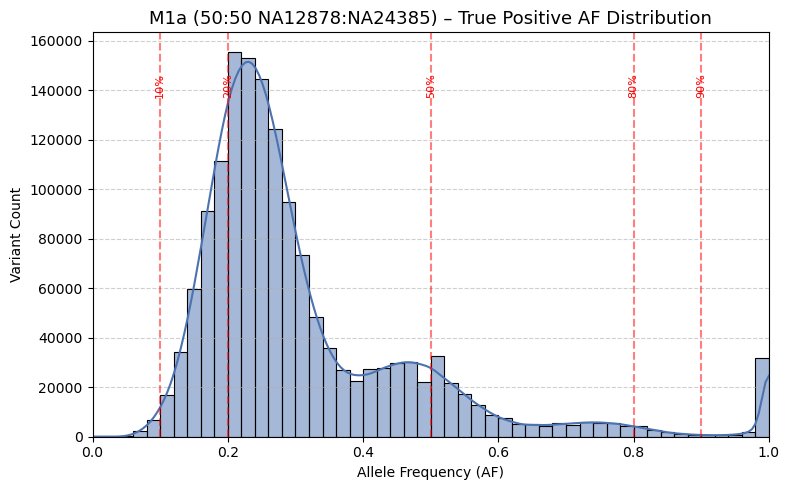

{'True Positives': 1176445, 'False Negatives': 418505, 'False Positives': 4881571, 'Sensitivity (Recall)': 0.7376, 'Specificity (Precision)': 0.1942, 'F1 Score': 0.3074}


In [39]:
metrics_M1a, TP_M1a = variant_benchmark_with_TP(
    truth_df=HG002_unique_to_HG001,
    test_df=M1a_decomposed_short_chr,
    af_col="AF",
    title="M1a (50:50 NA12878:NA24385) – True Positive AF Distribution"
)
print(metrics_M1b)


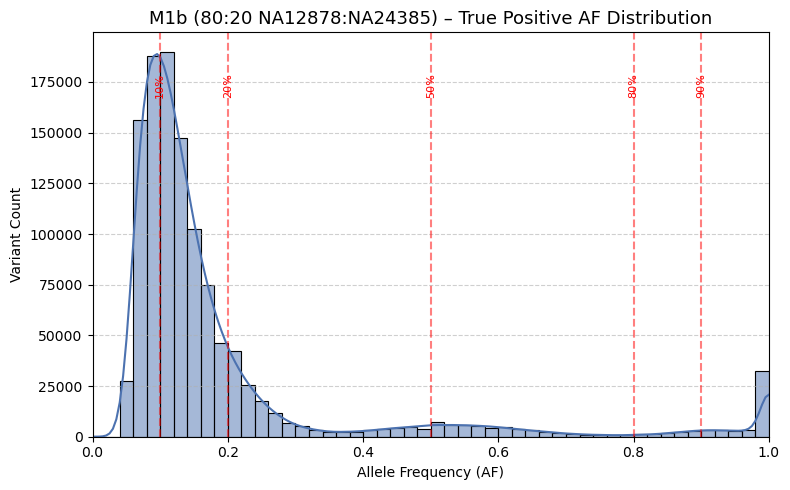

{'True Positives': 1176445, 'False Negatives': 418505, 'False Positives': 4881571, 'Sensitivity (Recall)': 0.7376, 'Specificity (Precision)': 0.1942, 'F1 Score': 0.3074}


In [38]:
metrics_M1b, TP_M1b = variant_benchmark_with_TP(
    truth_df=HG002_unique_to_HG001,
    test_df=M1b_decomposed_short_chr,
    af_col="AF",
    title="M1b (80:20 NA12878:NA24385) – True Positive AF Distribution"
)
print(metrics_M1b)


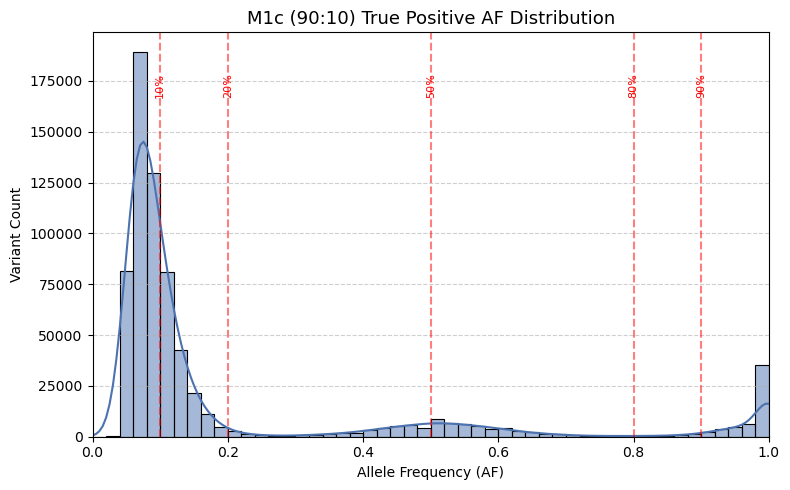

In [40]:
metrics_M1c, TP_M1c = variant_benchmark_with_TP(
    truth_df=HG002_unique_to_HG001,
    test_df=M1c_decomposed_short_chr,
    af_col="AF",
    title="M1c (90:10) True Positive AF Distribution"
)


In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def variant_benchmark_with_TP_by_GT(truth_df, test_df, af_col="AF", gt_col="GT",
                                    title=None, expected_vafs=[0.1, 0.2, 0.5, 0.8, 0.9]):
    """
    Compare truth vs test VCFs, compute benchmarking metrics,
    and plot AF distributions for True Positives split by genotype (hom vs het).

    Parameters
    ----------
    truth_df : pd.DataFrame
        Truth variants (columns: CHROM, POS, REF, ALT)
    test_df : pd.DataFrame
        Observed variants (columns: CHROM, POS, REF, ALT, GT, AF)
    af_col : str
        Column name for allele frequency
    gt_col : str
        Column name for genotype
    title : str, optional
        Plot title prefix
    expected_vafs : list
        List of expected allele fractions to show as red reference lines
    """

    # --- Create unique keys ---
    truth_df = truth_df.copy()
    test_df = test_df.copy()
    truth_df["VAR_KEY"] = truth_df["CHROM"].astype(str) + "_" + truth_df["POS"].astype(str) + "_" + truth_df["REF"] + "_" + truth_df["ALT"]
    test_df["VAR_KEY"] = test_df["CHROM"].astype(str) + "_" + test_df["POS"].astype(str) + "_" + test_df["REF"] + "_" + test_df["ALT"]

    truth_set = set(truth_df["VAR_KEY"])
    test_set = set(test_df["VAR_KEY"])

    # --- Classify variants ---
    TP = truth_set & test_set
    FN = truth_set - test_set
    FP = test_set - truth_set

    TP_df = test_df[test_df["VAR_KEY"].isin(TP)].copy()
    TP_df[af_col] = pd.to_numeric(TP_df[af_col], errors="coerce")
    TP_df = TP_df.dropna(subset=[af_col])

    # Normalize genotype strings
    TP_df["GT_norm"] = TP_df[gt_col].astype(str).str.replace("|", "/")

    # --- Split by genotype ---
    hom_df = TP_df[TP_df["GT_norm"] == "1/1"]
    het_df = TP_df[TP_df["GT_norm"].isin(["0/1", "1/0"])]

    # --- Metrics ---
    TP_count = len(TP)
    FN_count = len(FN)
    FP_count = len(FP)
    sensitivity = TP_count / (TP_count + FN_count) if (TP_count + FN_count) else 0
    specificity = TP_count / (TP_count + FP_count) if (TP_count + FP_count) else 0
    f1_score = (2 * sensitivity * specificity) / (sensitivity + specificity) if (sensitivity + specificity) else 0

    metrics = {
        "True Positives": TP_count,
        "False Negatives": FN_count,
        "False Positives": FP_count,
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "F1 Score": round(f1_score, 4)
    }

    # --- Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    plt.suptitle(title or "True Positive AF Distribution by Genotype", fontsize=15, fontweight="bold")

    # HOM (1/1)
    sns.histplot(hom_df[af_col], bins=40, kde=True, color="#55A868", edgecolor="black", ax=axes[0])
    axes[0].set_title(f"Homozygous (1/1) – n={len(hom_df)}")
    axes[0].set_xlabel("Allele Frequency (AF)")
    axes[0].set_ylabel("Variant Count")
    axes[0].set_xlim(0, 1)
    axes[0].grid(axis="y", linestyle="--", alpha=0.6)

    # HET (0/1)
    sns.histplot(het_df[af_col], bins=40, kde=True, color="#4C72B0", edgecolor="black", ax=axes[1])
    axes[1].set_title(f"Heterozygous (0/1,1/0) – n={len(het_df)}")
    axes[1].set_xlabel("Allele Frequency (AF)")
    axes[1].set_xlim(0, 1)
    axes[1].grid(axis="y", linestyle="--", alpha=0.6)

    # --- Add expected AF reference lines ---
    for ax in axes:
        for af in expected_vafs:
            ax.axvline(af, color="red", linestyle="--", alpha=0.5)
            ax.text(af, ax.get_ylim()[1]*0.9, f"{int(af*100)}%", color="red",
                    rotation=90, ha="center", va="top", fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    return metrics, TP_df, hom_df, het_df


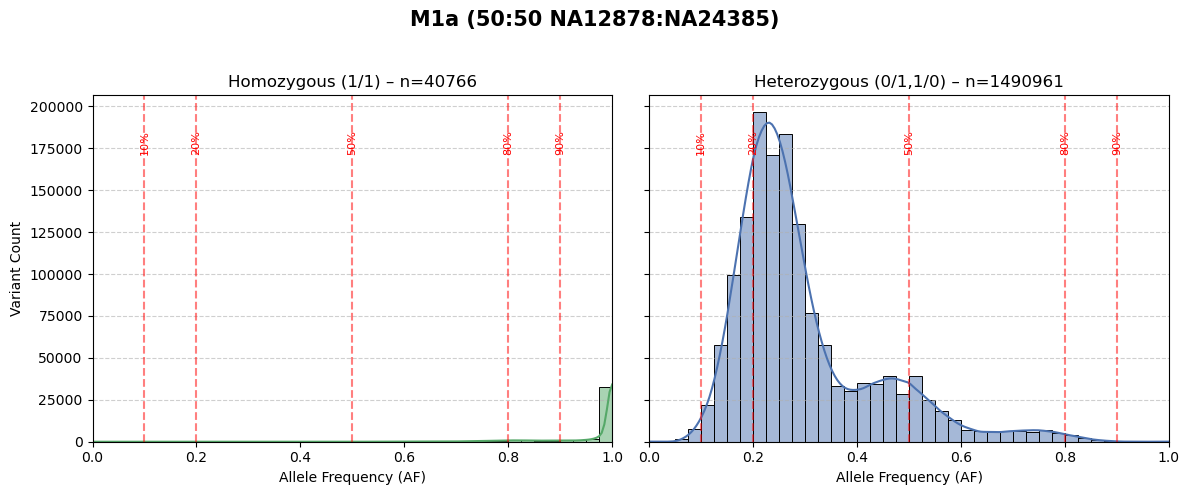

In [42]:
metrics_M1a, TP_M1a, TP_M1a_hom, TP_M1a_het = variant_benchmark_with_TP_by_GT(
    truth_df=HG002_unique_to_HG001,
    test_df=M1a_decomposed_short_chr,
    af_col="AF",
    gt_col="GT",
    title="M1a (50:50 NA12878:NA24385)"
)

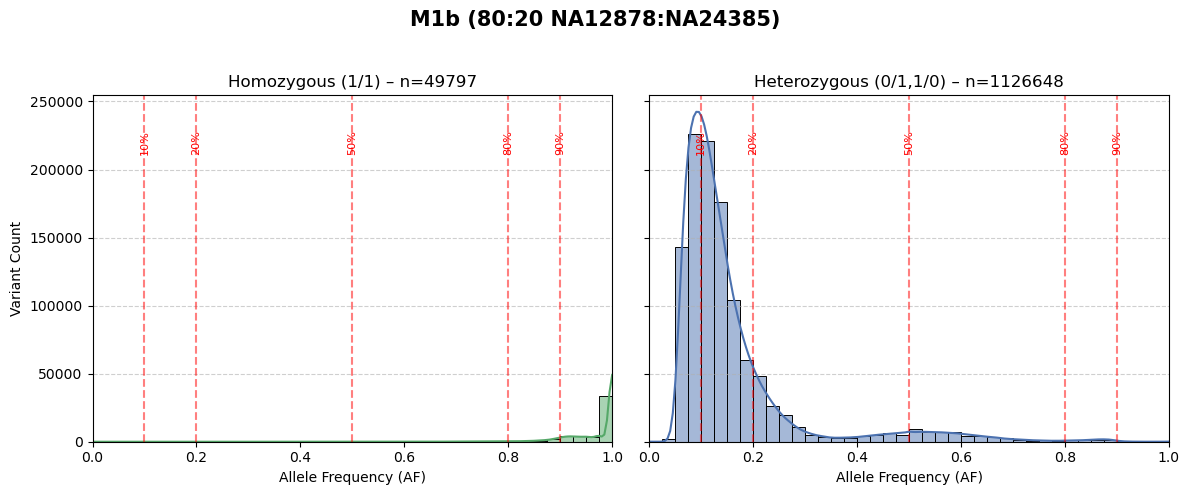

In [43]:
metrics_M1b, TP_M1b, TP_M1b_hom, TP_M1b_het = variant_benchmark_with_TP_by_GT(
    truth_df=HG002_unique_to_HG001,
    test_df=M1b_decomposed_short_chr,
    af_col="AF",
    gt_col="GT",
    title="M1b (80:20 NA12878:NA24385)"
)

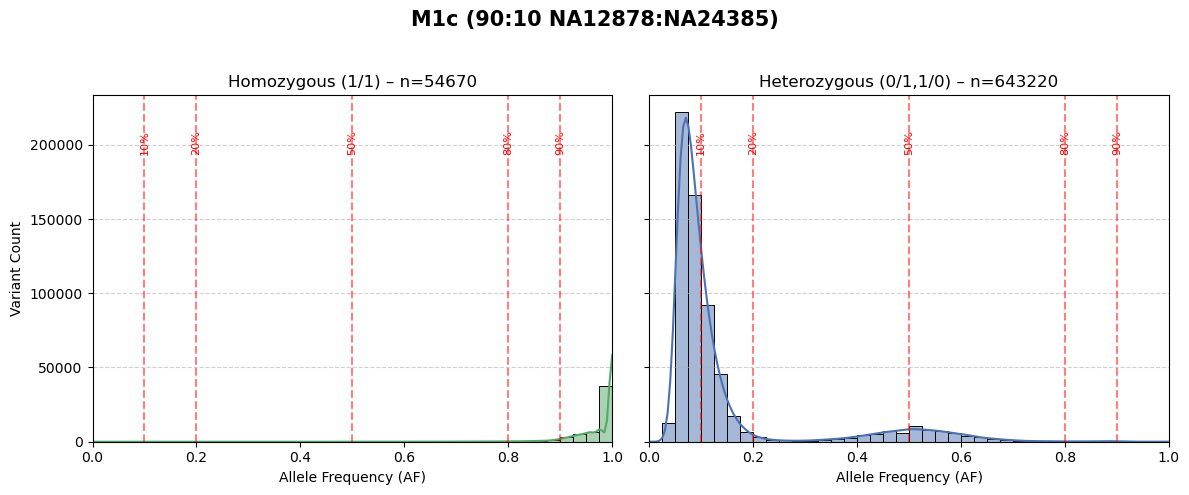

In [44]:
metrics_M1c, TP_M1c, TP_M1c_hom, TP_M1c_het = variant_benchmark_with_TP_by_GT(
    truth_df=HG002_unique_to_HG001,
    test_df=M1c_decomposed_short_chr,
    af_col="AF",
    gt_col="GT",
    title="M1c (90:10 NA12878:NA24385)"
)

In [73]:
# ✅ Example usage:
# Step 2. Merge to keep only matching coordinates in M1b
M1b_matched = M1b_decomposed.merge(
    HG001_unique_to_HG002,
    on=["CHROM", "POS","REF"],
    how="inner"
)
metrics = variant_benchmark(HG001_unique_to_HG002, M1b_matched)

print("\n=== Benchmarking Results ===")
for k, v in metrics.items():
    print(f"{k:25s}: {v:,}")


KeyError: 'ALT'

## For combined unique variants

In [ ]:
# Loop over all sites.txt files
find . -type f -name "sites.txt" | while read file; do
    echo "Processing $file ..."
    
    # Output file in the same directory
    dir=$(dirname "$file")
    outfile="$dir/sites.annotated.txt"
    
    awk 'BEGIN{OFS="\t"} 
    {
        ref=$3;
        alt=$4;
        gt=$5;
        
        # Determine variant type
        if(length(ref)==1 && length(alt)==1) {
            vtype="SNP";
            vlen=1;
        } else if(length(ref) < length(alt)) {
            vtype="INS";
            vlen=length(alt)-length(ref);
        } else if(length(ref) > length(alt)) {
            vtype="DEL";
            vlen=length(ref)-length(alt);
        } else {
            vtype="MNP";
            vlen=length(ref); 
        }
        
        # Convert GT
        if(gt=="01") {
            gt_fmt="0/1";
        } else if(gt=="10") {
            gt_fmt="1/0";
        } else if(gt=="11") {
            gt_fmt="1/1";
        } else {
            gt_fmt=gt;  # keep original for other cases
        }
        
        # Print all columns + new ones
        print $1, $2, ref, alt, gt_fmt, vtype, vlen
    }' "$file" > "$outfile"
done


In [62]:
import os
import glob
import pandas as pd

# --- Base directory ---
base_dir = "/mnt/genomics/Vinisha/WGS/data"

# --- Find all sites.txt files recursively ---
files = glob.glob(f"{base_dir}/**/sites.annotated.txt", recursive=True)

print(f"Found {len(files)} files:\n")
for f in files:
    print(f)

# --- Load each file into a DataFrame with correct headers ---
dataframes = {}

for path in files:
    # Extract directory parts
    parent_dir = os.path.dirname(path)
    pair_dir = os.path.basename(parent_dir)  # e.g., compare_vcf_HG001_HG002
    pair_name = pair_dir.replace("compare_vcf_", "")  # e.g., HG001_HG002

    # Determine whether it's GIAB or In-house
    if "In_house_GIAB" in path:
        var_name = f"{pair_name}_private_in_house"
    else:
        var_name = f"{pair_name}_private"

    # Load as pandas DataFrame
    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=["CHROM", "POS", "REF", "ALT", "GT","VarType","VarLen"]
    )

    # Store in dictionary and globals
    dataframes[var_name] = df
    globals()[var_name] = df

    print(f"✅ Loaded {var_name}: {len(df)} variants")

# --- Show all loaded DataFrames ---
print("\nAvailable DataFrames:")
for name in dataframes.keys():
    print(f" - {name}")


Found 6 files:

/mnt/genomics/Vinisha/WGS/data/GIAB/bcftools/compare_vcf_HG002_HG005/sites.annotated.txt
/mnt/genomics/Vinisha/WGS/data/GIAB/bcftools/compare_vcf_HG001_HG005/sites.annotated.txt
/mnt/genomics/Vinisha/WGS/data/GIAB/bcftools/compare_vcf_HG001_HG002/sites.annotated.txt
/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/compare_vcf_NA24385_NA24631/sites.annotated.txt
/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/compare_vcf_NA12878_NA24385/sites.annotated.txt
/mnt/genomics/Vinisha/WGS/data/In_house_GIAB/compare_vcf_NA12878_NA24631/sites.annotated.txt
✅ Loaded HG002_HG005_private: 3282096 variants
✅ Loaded HG001_HG005_private: 3205569 variants
✅ Loaded HG001_HG002_private: 3029587 variants
✅ Loaded NA24385_NA24631_private_in_house: 4169645 variants
✅ Loaded NA12878_NA24385_private_in_house: 3860927 variants
✅ Loaded NA12878_NA24631_private_in_house: 4212182 variants

Available DataFrames:
 - HG002_HG005_private
 - HG001_HG005_private
 - HG001_HG002_private
 - NA24385_NA24631_privat

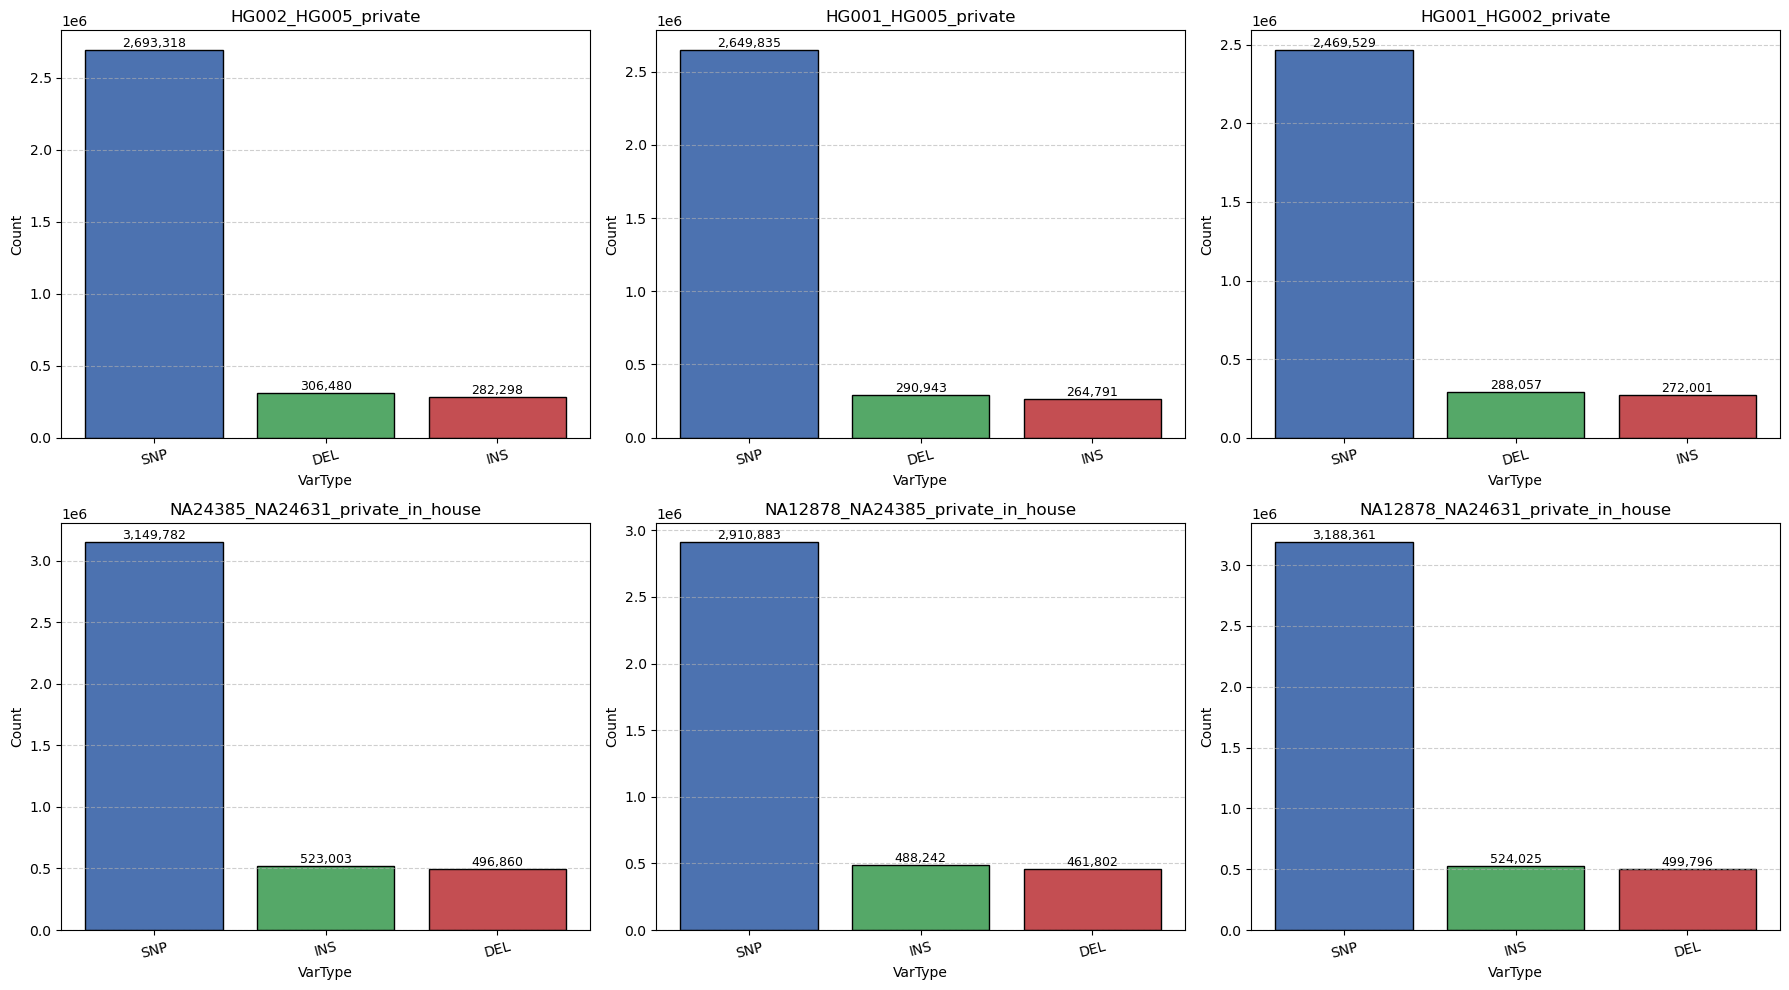

In [97]:
import matplotlib.pyplot as plt

def plot_variant_types_multi(dfs, sample_names, plot_type="bar"):
    """
    Plot variant type distributions for multiple sample DataFrames in a single figure.

    Parameters
    ----------
    dfs : list of pd.DataFrame
        Each DataFrame must contain a column named 'VarType'
    sample_names : list of str
        Names of the samples for labeling (same order as dfs)
    plot_type : str, default='bar'
        Type of plot: 'bar' or 'pie'
    """
    if len(dfs) != len(sample_names):
        raise ValueError("Length of dfs and sample_names must be the same.")

    n = len(dfs)
    cols = 3  # number of columns in the figure
    rows = (n + cols - 1) // cols  # compute rows needed

    fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*5))
    axes = axes.flatten()  # flatten in case of multiple rows

    colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

    for i, (df, name) in enumerate(zip(dfs, sample_names)):
        if "VarType" not in df.columns:
            raise ValueError(f"DataFrame for {name} must contain a 'VarType' column.")

        counts = df["VarType"].value_counts()

        if plot_type == "pie":
            axes[i].pie(
                counts.values,
                labels=counts.index,
                autopct="%1.1f%%",
                startangle=90,
                colors=colors[:len(counts)],
                wedgeprops={"edgecolor": "black"}
            )
            axes[i].set_title(f"{name}", fontsize=12)
        else:  # bar plot
            bars = axes[i].bar(
                counts.index,
                counts.values,
                color=colors[:len(counts)],
                edgecolor="black"
            )
            axes[i].set_title(f"{name}", fontsize=12)
            axes[i].set_xlabel("VarType")
            axes[i].set_ylabel("Count")
            axes[i].grid(axis='y', linestyle='--', alpha=0.6)
            axes[i].tick_params(axis='x', rotation=15)

            # Add value labels
            for bar in bars:
                axes[i].text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f"{int(bar.get_height()):,}",
                    ha='center',
                    va='bottom',
                    fontsize=9
                )

    # Remove any empty subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Example usage with your DataFrame variables:
dfs = [
    HG002_HG005_private,
    HG001_HG005_private,
    HG001_HG002_private,
    NA24385_NA24631_private_in_house,
    NA12878_NA24385_private_in_house,
    NA12878_NA24631_private_in_house
]

sample_names = [
    "HG002_HG005_private",
    "HG001_HG005_private",
    "HG001_HG002_private",
    "NA24385_NA24631_private_in_house",
    "NA12878_NA24385_private_in_house",
    "NA12878_NA24631_private_in_house"
]

plot_variant_types_multi(dfs, sample_names, plot_type="bar")


In [84]:
import pandas as pd

def summarize_indel_lengths(df):
    """
    Summarize how many insertions and deletions fall into specific length bins.
    Expects columns: 'VariantType' and 'VariantLength'
    """

    if not {"VarType", "VarLen"}.issubset(df.columns):
        raise ValueError("DataFrame must contain 'VariantType' and 'VariantLength' columns.")

    # Filter insertions and deletions
    indels = df[df["VarType"].isin(["INS", "DEL"])].copy()
    indels["VarLen"] = pd.to_numeric(indels["VarLen"], errors="coerce")
    indels = indels.dropna(subset=["VarLen"])

    # Define bins and labels
    bins = [0, 10, 20, 50,  100, 500, 1000, 5000, float("inf")]
    labels = ["1–10","11-20","21-50","51–100", "101–500", "501–1000", "1001–5000", ">5000"]

    # Bin the data
    indels["LengthRange"] = pd.cut(indels["VarLen"], bins=bins, labels=labels, right=True)

    # Count per type and bin
    summary = (
        indels.groupby(["VarType", "LengthRange"])
        .size()
        .unstack(fill_value=0)
        .astype(int)
    )

    # Add total per type
    summary["Total"] = summary.sum(axis=1)

    return summary


In [86]:
summary = summarize_indel_lengths(HG001_HG002_private)
summary

/tmp/ipykernel_29742/4215178301.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["VarType", "LengthRange"])


LengthRange,1–10,11-20,21-50,51–100,101–500,501–1000,1001–5000,>5000,Total
VarType,,,,,,,,,
DEL,264826,17555,5604,38,24,4,5,1,288057
INS,251053,15550,5216,89,66,9,18,0,272001


In [87]:
summary = summarize_indel_lengths(HG001_HG005_private)
summary

/tmp/ipykernel_29742/4215178301.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["VarType", "LengthRange"])


LengthRange,1–10,11-20,21-50,51–100,101–500,501–1000,1001–5000,>5000,Total
VarType,,,,,,,,,
DEL,268665,16964,5235,29,39,3,8,0,290943
INS,244908,15001,4756,43,49,8,25,1,264791


In [88]:
summary = summarize_indel_lengths(HG002_HG005_private)
summary

/tmp/ipykernel_29742/4215178301.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["VarType", "LengthRange"])


LengthRange,1–10,11-20,21-50,51–100,101–500,501–1000,1001–5000,>5000,Total
VarType,,,,,,,,,
DEL,282633,17965,5809,27,33,5,7,1,306480
INS,260803,15873,5420,98,71,15,17,1,282298


In [93]:
summary = summarize_indel_lengths(NA12878_NA24385_private_in_house)
summary

/tmp/ipykernel_29742/4215178301.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["VarType", "LengthRange"])


LengthRange,1–10,11-20,21-50,51–100,101–500,501–1000,1001–5000,>5000,Total
VarType,,,,,,,,,
DEL,413088,33571,14199,944,0,0,0,0,461802
INS,430181,37928,17530,2603,0,0,0,0,488242


In [94]:
summary = summarize_indel_lengths(NA12878_NA24631_private_in_house)
summary

/tmp/ipykernel_29742/4215178301.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["VarType", "LengthRange"])


LengthRange,1–10,11-20,21-50,51–100,101–500,501–1000,1001–5000,>5000,Total
VarType,,,,,,,,,
DEL,448116,35674,15042,964,0,0,0,0,499796
INS,464153,39456,17697,2717,2,0,0,0,524025


In [95]:
summary = summarize_indel_lengths(NA24385_NA24631_private_in_house)
summary

/tmp/ipykernel_29742/4215178301.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indels.groupby(["VarType", "LengthRange"])


LengthRange,1–10,11-20,21-50,51–100,101–500,501–1000,1001–5000,>5000,Total
VarType,,,,,,,,,
DEL,445176,35821,14909,954,0,0,0,0,496860
INS,462636,39570,18079,2716,2,0,0,0,523003


In [104]:
NA24385_NA24631_private_in_house["GT"].unique()

array(['1/0', '0/1'], dtype=object)